# TSARA, Phase 5 — the continuous rolling state

**A walkthrough you can run, change and try to break.** Every number and figure
below is produced by the package from data manufactured inside this notebook,
where the true background under every plume is known. No real measurement is
read, and nothing needs mounting. Notebook `05b` runs the same operations on the
campaign archive.

---

## How to use this notebook

1. **Run everything once** (*Run All*, about a minute).
2. **Every section stands on its own.** Each opens with a **parameters cell**: a
   short list of CAPITALISED names, each commented with what it controls. Change
   a value, then run that section's cells from the parameters cell down to the
   next heading. A section reads nothing another section made; all of them
   share only the two setup cells below.
3. **Every section prints checks.** A line beginning ✔ is a claim about TSARA,
   compared *as it ran* against a calculation written independently in this
   notebook: a loop written from the definition, a closed form, the
   generator's answer key, or random draws whose truth is known. The checks are
   written to hold at *any* parameters you choose. If you ever see ✘, you have
   found an edge case worth understanding or a bug. Either way, bring it back.
4. **"Try it"** notes after each section suggest a change and say what should
   happen. Each prediction was run before this notebook was committed.
5. **Section 10** collects every check into one scoreboard, and lists what is
   known to be imperfect.

When a section describes package code, it names the function and the file, for
example `rolling_quantile` in `src/tsara/rolling/quantile.py`. That code is
commented so that it can be read alongside.

---

## What this phase delivers

You decided on 2026-09-24 that the continuous rolling state is **per stream, at
native rate, beside the readings**: for every reading of every instrument and
every point of a window × quantile sweep, the baseline, the enhancement and the
noise scale detection thresholds are quoted in. Not a grid product. Phase 5
built that, and this notebook shows each part doing its job with the truth
beside it:

| | Property | Tested in |
|---|---|---|
| 1 | **One weighted quantile**, defined once: each reading counts by the share of its cell inside the window | §1, §2 |
| 2 | **A baseline is stated with its window**: what is baseline at one window is signal at another | §2 |
| 3 | **Blank with the reason recorded, never an error**: a window too thin for a quantile, or a reading too wide for a window | §3, §4 |
| 4 | **Options for a sparse instrument**: another instrument's baseline of the same field, or a declared constant | §5, §6 |
| 5 | **Honest uncertainty on the baseline and the enhancement**, and enhancements never clipped | §2, §7 |
| 6 | **A noise scale by provenance**: declared when there is one, estimated when there is not, labelled either way, floored where a logger writes in steps | §8 |
| 7 | **The state saves, reloads exactly, and joins like a stream** | §9 |

What this phase does **not** do: plume detection (Phase 6), regression and the
stability cube (Phase 7). Section 8 measures one thing it hands to Phase 6.

---

## Vocabulary used throughout

| term | meaning |
|---|---|
| **cell** | the interval of air one row describes. Stored as `time_bnds` (start, stop); `time` is its midpoint |
| **window** | a duration centred on a reading's cell, over which a rolling statistic is taken. A window is itself a cell |
| **baseline at window *w*** | the low quantile of a variable over the window of length *w* around a reading; always stated with its window |
| **enhancement** | reading minus baseline, at that window and quantile; negative in clean air, never clipped |
| **sweep point** | one (window, quantile) pair of the configured sweep; the state has one baseline per reading per sweep point |
| **overlap weight** | how much of a reading's cell (in nanoseconds) falls inside a window |
| **count rule** | a window holding fewer readings than `min_readings` (default ⌈1/q⌉) for a quantile is blank at that quantile |
| **width rule** | a window holding a reading at least twice as wide as itself is blank: a wide reading is not stood on a narrow window |
| **blank** | a sweep point with no baseline at a reading, with the reason recorded beside it |
| **noise scale** | the one-sigma random noise of a variable at a reading: declared, reported, or estimated from the record (`empirical`) |
| **provenance** | where a number came from: `declared`, `reported`, `inferred`, `assumed`, `empirical` |
| **field** | a physical quantity of the atmosphere, e.g. `benzene`; two instruments measuring one field share one background |
| **source** | an *emission* source only: a landfill, a gas line, a refinery. Never the input of a join or where a number came from |

---
## Setup (run these two cells first)

The first cell is the **toolkit**: imports, the figure style shared by
notebooks 01–05, helpers for building and drawing streams, and the
**reference implementations** every check compares TSARA against. The second
holds the **campaign recipes**, one function per synthetic campaign, whose
keyword arguments are the knobs the sections expose.

In [1]:
# =============================================================================
# TOOLKIT. Every section needs this cell and nothing else from other sections.
# =============================================================================
import logging
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from tsara import setup_logging
from tsara.align import bin_streams_onto_cells
from tsara.config.analysis import BaselineConfig, DetectionConfig
from tsara.config.synthetic import SyntheticConfig
from tsara.core.support import CellBounds, stream_cells
from tsara.rolling import (
    TsaraRollingError,
    load_state,
    noise_scale,
    rolling_quantile,
    rolling_state,
    save_state,
    weighted_quantile,
    window_cells,
)
from tsara.synthetic import generate

SECOND = 1_000_000_000  # TSARA keeps every time as integer nanoseconds

# The shipped example campaign, found from the repository root or from this
# notebook's own directory, whichever the kernel was started in.
EXAMPLE_CONFIG = next(
    root / "synthetic_example.yaml"
    for root in (Path("examples/configs"), Path("../configs"), Path("configs"))
    if (root / "synthetic_example.yaml").is_file()
)

# --- 1. figure style (identical to notebooks 01-04) --------------------------
C1, C2, C3 = "#0072b2", "#e69f00", "#009e73"  # Okabe-Ito blue, amber, green: colour-blind safe
C4 = "#cc79a7"  # Okabe-Ito purple, for a fourth series
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so matplotlib draws no line across a gap.

    A plotted line is a straight segment between neighbouring points, so a hole
    in a record would otherwise render as a smooth ramp across it: exactly the
    interpolation TSARA refuses to perform on a gas.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


def overview_strip(ax, clock, values, window, label):
    """Draw the whole record thinly and shade the zoomed window: where the figure below sits."""
    clock, values = break_gaps(clock, values)
    ax.plot(clock, values, color=MUTED, lw=0.5)
    ax.axvspan(window[0], window[1], color=C2, alpha=0.25, lw=0)
    ax.set_yticks([])
    ax.set_ylabel(label, fontsize=8, color=MUTED)
    ax.tick_params(axis="x", labelsize=7.5)
    hhmm(ax)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)


# --- 2. streams and cells -----------------------------------------------------
def cells_of(stream):
    """Return a stream's cells as CellBounds: integer-nanosecond starts and stops."""
    edges = stream["time_bnds"].values.astype("datetime64[ns]").astype("int64")
    return CellBounds(start_ns=edges[:, 0].copy(), stop_ns=edges[:, 1].copy())


def uniform_cells(start, width_s, count):
    """Return `count` abutting cells, each `width_s` seconds wide, from `start`."""
    first = pd.Timestamp(start).value
    width = int(round(width_s * SECOND))
    starts = first + np.arange(count, dtype=np.int64) * width
    return CellBounds(start_ns=starts, stop_ns=starts + width)


def make_stream(start_ns, stop_ns, variables, attrs=None, cell_methods="time: point"):
    """Build the smallest dataset TSARA accepts as a stream: values over `time`, cells beside.

    `variables` maps a name to its values; every variable is a gas unless `attrs`
    says otherwise (e.g. {"wind_dir": {"role": "met", "circular": 1}}).
    """
    start_ns = np.asarray(start_ns, dtype=np.int64)
    stop_ns = np.asarray(stop_ns, dtype=np.int64)
    attrs = attrs or {}
    stream = xr.Dataset(
        {
            name: (
                "time",
                np.asarray(values, dtype=float),
                {
                    "units": "ppb",
                    "role": "gas",
                    "field": name,
                    "cell_methods": cell_methods,
                    **attrs.get(name, {}),
                },
            )
            for name, values in variables.items()
        },
        coords={
            "time": (start_ns + (stop_ns - start_ns) // 2).astype("datetime64[ns]"),
            "time_bnds": (
                ("time", "nv"),
                np.stack([start_ns, stop_ns], axis=1).astype("datetime64[ns]"),
            ),
        },
        attrs={"tsara_stage": "synthetic"},
    )
    stream["time"].attrs["bounds"] = "time_bnds"  # the CF link from an axis to its cell edges
    return stream


def measured(stream):
    """Drop the generator's answer-key columns (`truth_*`), keeping what an instrument reports."""
    return stream.drop_vars([v for v in stream.data_vars if str(v).startswith("truth_")])


def sweep(windows=("2min", "10min", "60min"), quantiles=(0.01, 0.05, 0.10), **more):
    """Return a BaselineConfig for a sweep, the shape `analysis_example.yaml` uses by default."""
    return BaselineConfig.model_validate(
        {"windows": list(windows), "quantiles": list(quantiles), **more}
    )


# --- 3. reference implementations --------------------------------------------
# Written from the definitions in METHODS §6.3, §6.4, §6.7 and §2.5, deliberately
# slow and plain, one window at a time. They share no code with TSARA: no binary
# search, no block of windows, no sort carried across quantiles. If TSARA and
# these agree, it is because both compute the definition.


def reference_weighted_quantile(values, weights, q):
    """Return the weighted quantile of one window, from the definition (METHODS §6.3).

    Sort the contributing readings by value. A reading contributes when it holds
    a finite value and a positive weight (its overlap with the window). Its
    POSITION is the midpoint of its weight mass over the total:
        position_k = (w_1 + ... + w_k - w_k / 2) / (w_1 + ... + w_N)
    The q-quantile is the value interpolated linearly at position q, held at the
    lowest reading below the first position and at the highest above the last.
    """
    values, weights = np.asarray(values, dtype=float), np.asarray(weights, dtype=float)
    use = np.isfinite(values) & (weights > 0)
    if not use.any():
        return np.nan
    order = np.argsort(values[use], kind="stable")
    v, w = values[use][order], weights[use][order]
    cumulative = np.cumsum(w)
    positions = (cumulative - w / 2) / cumulative[-1]
    return float(np.interp(q, positions, v))  # np.interp holds the end values outside the range


def reference_rolling(reading_cells, values, window_s, q, min_readings=1):
    """Return the baseline at every reading, one window at a time (METHODS §6.3, §6.4).

    For each reading k, the window is [midpoint_k - w/2, midpoint_k + w/2). Every
    reading's overlap with it is its weight. Returns the quantile (blank where the
    window holds fewer than `min_readings` contributing readings), the count and
    the coverage (contributing overlap over the window's duration).
    """
    values = np.asarray(values, dtype=float)
    n = len(reading_cells)
    width = int(round(window_s * SECOND))
    midpoints = reading_cells.start_ns + (reading_cells.stop_ns - reading_cells.start_ns) // 2
    out, count, coverage = np.full(n, np.nan), np.zeros(n, dtype=int), np.zeros(n)
    for k in range(n):
        start = int(midpoints[k]) - width // 2
        stop = start + width
        overlap = np.minimum(reading_cells.stop_ns, stop) - np.maximum(
            reading_cells.start_ns, start
        )
        overlap = np.clip(overlap, 0, None).astype(float)
        use = (overlap > 0) & np.isfinite(values)
        count[k] = int(use.sum())
        coverage[k] = overlap[use].sum() / width
        if count[k] >= min_readings and use.any():
            out[k] = reference_weighted_quantile(values[use], overlap[use], q)
    return out, count, coverage


def reference_woodruff(values, weights, q):
    """Woodruff's one-sigma for one window's quantile (METHODS §6.7).

    Read the same sorted window at positions q +- sqrt(q (1 - q) / N_eff), N_eff
    being Kish's effective count (sum w)^2 / sum w^2, and report half the interval.
    """
    values, weights = np.asarray(values, dtype=float), np.asarray(weights, dtype=float)
    use = np.isfinite(values) & (weights > 0)
    if not use.any():
        return np.nan
    w = weights[use]
    n_eff = w.sum() ** 2 / np.sum(w**2)
    error = np.sqrt(q * (1 - q) / n_eff)
    low = reference_weighted_quantile(values, weights, max(q - error, 0.0))
    high = reference_weighted_quantile(values, weights, min(q + error, 1.0))
    return (high - low) / 2


def reference_diff_mad(reading_cells, values, window_s, factor=1.5, min_samples=10):
    """Return the robust first-difference noise scale at every reading, window by window (§2.5).

    A sample is |x_{i+1} - x_i| for consecutive FINITE readings, on the cell between
    their midpoints; a sample across a dropout (midpoints farther apart than `factor`
    times the median spacing) is dropped. Each window takes the weighted median of the
    samples touching it, scaled by 1.4826 / sqrt(2); fewer than `min_samples` is blank.
    """
    values = np.asarray(values, dtype=float)
    finite = np.flatnonzero(np.isfinite(values))
    n = len(reading_cells)
    out = np.full(n, np.nan)
    if finite.size < 2:
        return out
    midpoints = reading_cells.start_ns + (reading_cells.stop_ns - reading_cells.start_ns) // 2
    sample_mid = midpoints[finite]
    spacing = np.diff(sample_mid)
    keep = spacing <= factor * np.median(spacing)
    samples = np.abs(np.diff(values[finite]))[keep]
    sample_start, sample_stop = sample_mid[:-1][keep], sample_mid[1:][keep]
    width = int(round(window_s * SECOND))
    for k in range(n):
        start = int(midpoints[k]) - width // 2
        stop = start + width
        overlap = np.clip(np.minimum(sample_stop, stop) - np.maximum(sample_start, start), 0, None)
        use = overlap > 0
        if use.sum() >= min_samples:
            median = reference_weighted_quantile(samples[use], overlap[use].astype(float), 0.5)
            out[k] = 1.4826 * median / np.sqrt(2.0)
    return out


# --- 4. the scoreboard -------------------------------------------------------
CHECKS = {}  # claim -> (held?, detail); section 10 prints them all


def start_section(tag):
    """Forget a section's earlier checks, so re-running it replaces rather than piles up."""
    for claim in [c for c in CHECKS if c.startswith(tag + " ")]:
        del CHECKS[claim]


def check(claim, holds, detail=""):
    """Record one claim about TSARA and print whether it held just now."""
    CHECKS[claim] = (bool(holds), detail)
    mark = "✔" if holds else "✘ DOES NOT HOLD:"
    print(f"  {mark} {claim}" + (f"   [{detail}]" if detail else ""))


def sampling_tolerance(n):
    """Three standard errors of a standard deviation estimated from n random draws.

    The standard deviation of n normal draws scatters about its true value by
    about 1/sqrt(2(n-1)) in relative terms; a ratio within three of those of 1
    is agreement. Fewer draws widen the band, so the checks stay honest when a
    Monte Carlo is shrunk to run faster.
    """
    return 3.0 / np.sqrt(2.0 * (n - 1))


def same(a, b):
    """Exact equality, NaN matching NaN."""
    return bool(np.array_equal(np.asarray(a), np.asarray(b), equal_nan=True))


# --- 5. logging, and a scratch directory --------------------------------------
_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)  # the bundle section writes here


def scrub_work_dir(record):
    """Show the scratch directory as <work> in TSARA's log messages."""
    if isinstance(record.msg, str):
        record.msg = record.msg.replace(str(WORK), "<work>")
    if isinstance(record.args, tuple):
        record.args = tuple(
            str(a).replace(str(WORK), "<work>") if str(WORK) in str(a) else a for a in record.args
        )
    return True


# TSARA is silent in a notebook until logging is configured; its warnings are
# part of what several sections demonstrate.
for handler in setup_logging(logging.WARNING).handlers:
    handler.addFilter(scrub_work_dir)

print("toolkit ready")

toolkit ready


In [2]:
# =============================================================================
# CAMPAIGN RECIPES. Each builds one synthetic campaign with the generator from
# notebook 01. The generator records the truth it used -- the plume-free
# background of every field at every instant, and each instrument's true random
# sigma -- so every result can be checked against it. Each keyword is a knob;
# its default is what the section that introduces the campaign uses.
# =============================================================================


def _field(offset, units="ppb", **background):
    """Return one atmosphere field: a gas at plume-free level `offset`, plus optional terms."""
    return {
        "role": "gas",
        "units": units,
        "background": {"kind": "parametric", "offset": offset, **background},
    }


def _measure(noise=None, name=None, quantization=None):
    """Return how an instrument measures a field: 1-sigma noise, own name, rounding step."""
    spec = {}
    if noise:
        spec["uncertainty"] = {"random": {"absolute": noise}}
    if name:
        spec["name"] = name
    if quantization:
        spec["quantization"] = quantization
    return spec


def landfill_campaign(
    *,
    seed=11,
    duration="6h",
    rate="1s",
    noise_ppb=0.7,
    landfill_per_hour=0.6,
    landfill_sigma="8min",
    landfill_median_ppb=60.0,
    blips_per_hour=10.0,
    blip_sigma="6s",
    blip_tau="12s",
    blip_median_ppb=120.0,
    diurnal_ppb=0.0,
):
    """Build METHODS §6.1's worked case: broad landfill plumes with short gas blips on top.

    One methane field at 1900 ppb, seen by one analyzer (`analyzer`) sampling
    every `rate` with `noise_ppb` of white noise. Two emitters: a landfill whose
    plumes last tens of minutes, and a gas line whose blips last seconds. What a
    baseline at a given window follows, and what it leaves standing, is the
    whole question of section 2.
    """
    sources = {}
    if landfill_per_hour:
        sources["landfill"] = {
            "rate_per_hour": landfill_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "gaussian", "sigma": landfill_sigma},
            "amplitude": {"kind": "lognormal", "median": landfill_median_ppb, "sigma_log": 0.3},
        }
    if blips_per_hour:
        sources["gas_line"] = {
            "rate_per_hour": blips_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "emg", "sigma": blip_sigma, "tau": blip_tau},
            "amplitude": {"kind": "lognormal", "median": blip_median_ppb, "sigma_log": 0.4},
        }
    campaign_description = {
        "name": "landfill_demo",
        "seed": seed,
        "start": "2026-06-15T10:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "fields": {"ch4": _field(1900.0, diurnal_amplitude=diurnal_ppb)},
            "sources": sources,
        },
        "instruments": {
            "analyzer": {"native_rate": rate, "measures": {"ch4": _measure(noise_ppb)}}
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def flat_campaign(*, seed=3, duration="1h", rate="1s", noise_ppb=0.7, quantization=None):
    """Build clean air: a flat 1900 ppb methane background, one analyzer, white noise, no plumes.

    `quantization` rounds what the analyzer writes to that step, the shape of a
    logger that reports in 0.01 ppm increments (section 8).
    """
    campaign_description = {
        "name": "flat_demo",
        "seed": seed,
        "start": "2026-06-16T09:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {"fields": {"ch4": _field(1900.0)}},
        "instruments": {
            "analyzer": {
                "native_rate": rate,
                "measures": {"ch4": _measure(noise_ppb, quantization=quantization)},
            }
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def minute_campaign(*, seed=7, duration="6h", noise_ppb=0.4, plumes_per_hour=4.0):
    """Build a stationary suite reporting 60 s MEANS, start-labelled, as ICARTT files usually are.

    One methane field with occasional plumes, one instrument (`suite`). Sixty
    readings an hour is what a 2 min window cannot hold twenty of (section 3),
    and what a 30 s window would have to stand on a reading twice its own width
    for (section 4).
    """
    sources = {}
    if plumes_per_hour:
        sources["pad"] = {
            "rate_per_hour": plumes_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "gaussian", "sigma": "3min"},
            "amplitude": {"kind": "lognormal", "median": 80.0, "sigma_log": 0.3},
        }
    campaign_description = {
        "name": "minute_demo",
        "seed": seed,
        "start": "2026-06-17T00:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {"fields": {"ch4": _field(1900.0)}, "sources": sources},
        "instruments": {
            "suite": {
                "native_rate": "60s",
                "support": {"method": "mean", "label": "start", "subsamples": 64},
                "measures": {"ch4": _measure(noise_ppb)},
            }
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def canister_campaign(
    *,
    seed=21,
    duration="8h",
    ptr_noise_ppb=0.02,
    fill_width="15s",
    fill_every="530s",
    fill_jitter="200s",
    canister_noise_ppb=0.01,
    plumes_per_hour=3.0,
    plume_sigma="3min",
    plume_median_ppb=1.5,
):
    """Build a whole-air canister sampler beside a dense benzene analyzer of the same field.

    Atmosphere: one field, `benzene`, at 0.5 ppb with a refinery's plumes.
    `ptr`   measures benzene every second (a PTR-MS's shape).
    `iwas`  measures benzene in canisters, each the mean over a `fill_width` fill,
            roughly every `fill_every` (plus or minus `fill_jitter`).
    Both sample one benzene, so the PTR's baseline is the canister's background
    too -- which is what section 5's `from_field` adopts.
    """
    campaign_description = {
        "name": "canister_demo",
        "seed": seed,
        "start": "2026-06-16T15:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "fields": {"benzene": _field(0.5)},
            "sources": {
                "refinery": {
                    "rate_per_hour": plumes_per_hour,
                    "reference_species": "benzene",
                    "shape": {"kind": "gaussian", "sigma": plume_sigma},
                    "amplitude": {
                        "kind": "lognormal",
                        "median": plume_median_ppb,
                        "sigma_log": 0.5,
                    },
                }
            },
        },
        "instruments": {
            "ptr": {"native_rate": "1s", "measures": {"benzene": _measure(ptr_noise_ppb)}},
            "iwas": {
                "native_rate": fill_every,
                "timestamp_jitter": fill_jitter,
                "support": {"method": "mean", "width": fill_width},
                "measures": {"benzene": _measure(canister_noise_ppb, name="benzene_can")},
            },
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


print("recipes ready")

recipes ready


---
## 1. One weighted quantile, by hand

**The question.** A baseline at window *w* is a low quantile of the readings in
a window centred on each reading, and a reading counts by the share of its cell
inside the window (`METHODS.md` §6.3). Before rolling anything, what exactly is
"the *q*-quantile of readings with weights"?

The definition TSARA uses (`weighted_quantile` in `src/tsara/rolling/quantile.py`)
is drawn below for a handful of readings. Sort them by value. Lay each reading's
weight out as a block, in that order, so the blocks tile the interval from 0 to
the total weight. Each reading's **position** is the middle of its block, as a
fraction of the total. The quantile at *q* is the value read off by walking to
fraction *q* and interpolating between the two positions that bracket it; below
the first position it is the lowest reading, above the last the highest. With
equal weights the positions are (*k* − ½)/*N*, Hazen's rule, which numpy calls
`method="hazen"`.

In [3]:
# ---- PARAMETERS (section 1) --------------------------------------------------
VALUES = [1903.2, 1899.1, 1901.5, 1898.4, 1900.3, 1911.8]  # six readings, any order
WEIGHTS = [1.0, 1.0, 0.5, 1.0, 1.0, 0.25]  # their overlaps with the window, in seconds
Q = 0.25  # the quantile to read off

readings sorted:  [1898.4, 1899.1, 1900.3, 1901.5, 1903.2, 1911.8]
weights:          [1.0, 1.0, 1.0, 0.5, 1.0, 0.25]   total 4.75
positions:        [0.105, 0.316, 0.526, 0.684, 0.842, 0.974]
quantile at q = 0.25: by hand 1898.881, TSARA 1898.881
  ✔ §1 TSARA's weighted quantile equals the one written from the definition
  ✔ §1 with equal weights it is numpy's Hazen rule, at every q
  ✔ §1 the order of the readings does not matter
  ✔ §1 a reading with no weight, or no value, takes no part


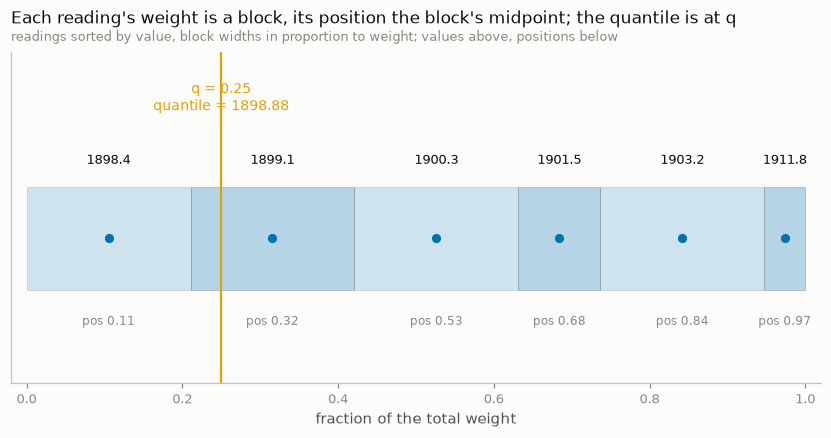

In [4]:
start_section("§1")
values, weights = np.asarray(VALUES, float), np.asarray(WEIGHTS, float)
order = np.argsort(values, kind="stable")
v, w = values[order], weights[order]
cumulative = np.cumsum(w)
positions = (cumulative - w / 2) / cumulative[-1]
by_hand = reference_weighted_quantile(values, weights, Q)
by_tsara = float(weighted_quantile(values, weights, [Q])[0])

print(f"readings sorted:  {np.round(v, 1).tolist()}")
print(f"weights:          {w.tolist()}   total {cumulative[-1]:g}")
print(f"positions:        {np.round(positions, 3).tolist()}")
print(f"quantile at q = {Q}: by hand {by_hand:.3f}, TSARA {by_tsara:.3f}")
check(
    "§1 TSARA's weighted quantile equals the one written from the definition", by_tsara == by_hand
)
equal = np.ones(values.size)
check(
    "§1 with equal weights it is numpy's Hazen rule, at every q",
    np.allclose(
        weighted_quantile(values, equal, [0.0, 0.1, 0.25, 0.5, 0.9, 1.0]),
        np.quantile(values, [0.0, 0.1, 0.25, 0.5, 0.9, 1.0], method="hazen"),
        rtol=1e-12,
    ),
)
check(
    "§1 the order of the readings does not matter",
    float(weighted_quantile(values[::-1], weights[::-1], [Q])[0]) == by_tsara,
)
check(
    "§1 a reading with no weight, or no value, takes no part",
    float(weighted_quantile(np.r_[values, 5000.0], np.r_[weights, 0.0], [Q])[0]) == by_tsara
    and float(weighted_quantile(np.r_[values, np.nan], np.r_[weights, 3.0], [Q])[0]) == by_tsara,
)

# Figure only from here: the weight blocks, their midpoints, and the walk to q.
fig, ax = plt.subplots(figsize=(9.5, 3.9))
left = np.r_[0.0, cumulative[:-1]] / cumulative[-1]
for k in range(v.size):
    ax.barh(
        0,
        w[k] / cumulative[-1],
        left=left[k],
        height=0.5,
        color=C1,
        alpha=0.18 + 0.1 * (k % 2),
        edgecolor=INK2,
        lw=0.6,
    )
    ax.plot(positions[k], 0, "o", color=C1, ms=5)
    ax.text(positions[k], 0.36, f"{v[k]:.1f}", ha="center", fontsize=8.5, color=INK)
    ax.text(positions[k], -0.42, f"pos {positions[k]:.2f}", ha="center", fontsize=7.8, color=MUTED)
ax.axvline(Q, color=C2, lw=1.4)
ax.text(Q, 0.62, f"q = {Q}\nquantile = {by_tsara:.2f}", ha="center", color=C2, fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.7, 0.9)
ax.set_yticks([])
finish(
    ax,
    "Each reading's weight is a block, its position the block's midpoint; the quantile is at q",
    "readings sorted by value, block widths in proportion to weight; values above, positions below",
    None,
    "fraction of the total weight",
    grid_axis=None,
)
plt.show()

**What to read off the output.** The six readings are sorted; each holds a
block whose width is its weight. Reading the walk to *q* = 0.25 lands between
two positions, and the quantile is interpolated between those two readings'
values, not between their positions. The half-weight reading (0.5 s inside the
window) holds a block half as wide, so it moves the positions of everything
above it by less than a whole reading would.

Two consequences matter for the rest of the notebook. First, with *N* equal
weights, the *q*-quantile is a blend of the two lowest readings whenever
*qN* + ½ < 2, and it *is* the lowest reading whenever *qN* + ½ ≤ 1: at
*q* = 0.05 that is 30 readings and 10 readings. A window that holds fewer than
about 1/*q* readings is reporting its minimum, not a background, which is why
§3's count rule defaults to ⌈1/*q*⌉. Second, a masked reading or a reading that
does not touch the window is simply absent, so blanks in a record do not move
the quantile; they thin the window.

**Try it.** `Q = 0.0` gives the lowest reading and `Q = 1.0` the highest,
whatever the weights. Set `WEIGHTS = [1, 1, 1, 1, 1, 1]` and the positions
become 1/12, 3/12, …, 11/12: Hazen's rule. Set the last weight to `100`: one
reading with almost all the weight sits at nearly every quantile, which is why
the width rule of §4 exists.

---
## 2. The rolling state on a campaign: what a window follows, and what it leaves

**The question.** `METHODS.md` §6.1 argues that there is no single true
baseline: a rolling low quantile over a window of length *w* follows everything
slower than about *w* and leaves what is shorter standing as enhancement. Is
that what the built state does, and does the baseline sit where the true
background is?

The campaign is §6.1's worked case, manufactured: a **landfill** whose plumes
last tens of minutes and a **gas line** whose blips last seconds, both on one
methane background the generator records at every instant
(`truth_background_ch4`). `rolling_state` in `src/tsara/rolling/state.py`
computes the baseline at every reading for every point of a window × quantile
sweep, the enhancement, and the sigmas of both, on the stream's own cells.

In [5]:
# ---- PARAMETERS (section 2) --------------------------------------------------
WINDOWS = ("2min", "20min", "2h")  # the sweep's windows, short -> long
QUANTILE = 0.05  # the quantile drawn and checked (one of the sweep's)
LANDFILL_SIGMA = "8min"  # how long a landfill plume lasts (Gaussian sigma)
BLIPS_PER_HOUR = 10.0  # how often the gas line's blips arrive
NOISE_PPB = 0.7  # the analyzer's white noise
VIEW_MINUTES = 150  # minutes of record drawn, centred on the largest landfill plume

state: {'time': 21600, 'baseline_window': 3, 'baseline_quantile': 1, 'nv': 2}
columns for ch4: ['baseline_ch4', 'ch4', 'coverage_window_ch4', 'enhancement_ch4', 'n_readings_window_ch4', 'noise_ch4', 'sigma_rand_baseline_ch4']


  ✔ §2 the baseline at 2min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2min


  ✔ §2 the baseline at 20min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 20min


  ✔ §2 the baseline at 2h is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2h
  ✔ §2 the enhancement is the reading minus the baseline, blank where either is
  ✔ §2 enhancements are never clipped: noise below the baseline stays negative
  ✔ §2 the baseline carries no cell_methods; the enhancement inherits the reading's


  ✔ §2 in clean air the 2min baseline sits z_q·σ below the true background   [median -1.15 ppb, expected -1.15, over 7893 readings]


  ✔ §2 in clean air the 20min baseline sits z_q·σ below the true background   [median -1.19 ppb, expected -1.15, over 463 readings]


  (no plume-free 2h window in this record; lower BLIPS_PER_HOUR to see one)


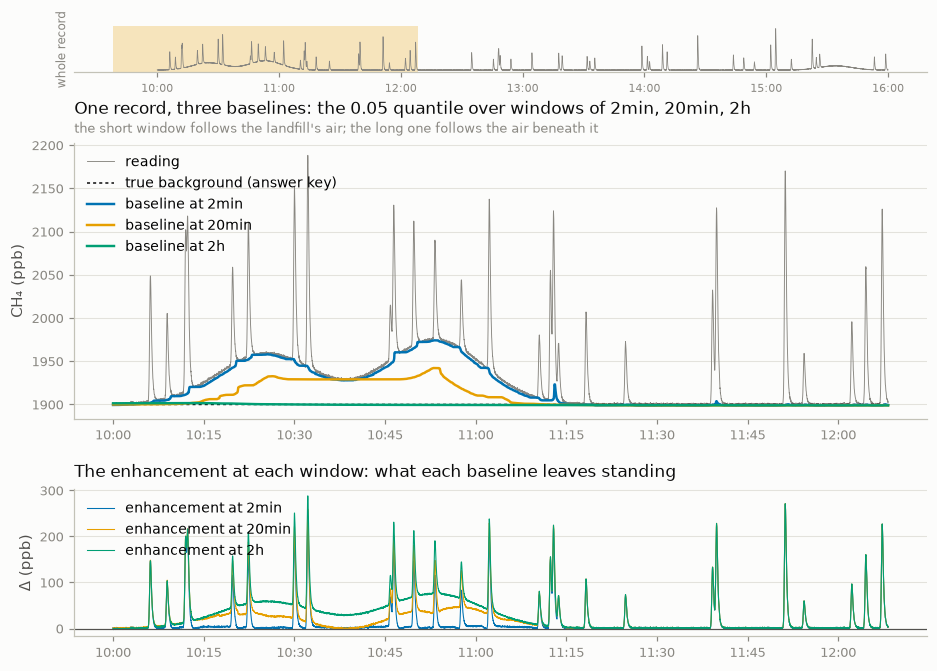

In [6]:
start_section("§2")
data = landfill_campaign(
    landfill_sigma=LANDFILL_SIGMA, blips_per_hour=BLIPS_PER_HOUR, noise_ppb=NOISE_PPB
)
stream = data.streams["analyzer"]
settings = sweep(windows=WINDOWS, quantiles=(QUANTILE,))
state = rolling_state(measured(stream), instrument="analyzer", baseline=settings)
truth = stream["truth_background_ch4"].values
readings = stream["ch4"].values
clock = stream["time"].values
baseline = state["baseline_ch4"]  # dims (time, baseline_window, baseline_quantile)
enhancement = state["enhancement_ch4"]
print(f"state: {dict(state.sizes)}")
print(f"columns for ch4: {sorted(v for v in state.data_vars if str(v).endswith('ch4'))}")

# The baseline at each window equals the definition applied window by window,
# blanked where the window holds fewer readings than the count rule asks.
cells = cells_of(stream)
minimum = settings.min_readings_for(QUANTILE)
for w, window in enumerate(WINDOWS):
    want, count, coverage = reference_rolling(
        cells, readings, pd.Timedelta(window).total_seconds(), QUANTILE, min_readings=minimum
    )
    got = baseline.values[:, w, 0]
    check(f"§2 the baseline at {window} is the definition, window by window", same(got, want))
    check(
        f"§2 its window count and coverage are the definition's, at {window}",
        same(state["n_readings_window_ch4"].values[:, w], count)
        and np.allclose(state["coverage_window_ch4"].values[:, w], coverage),
    )
check(
    "§2 the enhancement is the reading minus the baseline, blank where either is",
    same(enhancement.values, readings[:, None, None] - baseline.values),
)
check(
    "§2 enhancements are never clipped: noise below the baseline stays negative",
    np.nanmin(enhancement.values) < 0,
)
check(
    "§2 the baseline carries no cell_methods; the enhancement inherits the reading's",
    "cell_methods" not in baseline.attrs
    and enhancement.attrs.get("cell_methods") == stream["ch4"].attrs.get("cell_methods"),
)

# Against the truth: where the air is plume-free, a low quantile of noise sits a
# known offset below the background (-z_q sigma for Gaussian noise), and the
# longest window follows the background most closely.
from scipy.stats import norm  # noqa: E402  (the closed form the check is against)

quiet = stream["truth_enhancement_ch4"].values < 0.1 * NOISE_PPB
offset_expected = norm.ppf(QUANTILE) * NOISE_PPB
for w, window in enumerate(WINDOWS):
    gap = baseline.values[:, w, 0] - truth
    hold = np.isfinite(gap) & quiet
    # Only windows that are themselves quiet: a plume anywhere in a long window
    # raises its quantile, so the offset is exact only for clean windows.
    top_of_window = rolling_quantile(
        cells,
        stream["truth_enhancement_ch4"].values,
        window_cells(cells, pd.Timedelta(window).value),
        [0.99],
    ).values[:, 0]
    clean_window = top_of_window < 0.1 * NOISE_PPB
    hold &= clean_window
    if hold.sum() > 50:
        check(
            f"§2 in clean air the {window} baseline sits z_q·σ below the true background",
            abs(np.median(gap[hold]) - offset_expected) < 0.25 * NOISE_PPB,
            f"median {np.median(gap[hold]):+.2f} ppb, expected {offset_expected:+.2f}, "
            f"over {hold.sum()} readings",
        )
    else:
        print(f"  (no plume-free {window} window in this record; lower BLIPS_PER_HOUR to see one)")

# Figure only from here. The window is chosen from the answer key: centred on the
# largest landfill plume, so the figure shows the case it is about.
events = data.ground_truth.to_frame()
landfills = events[events["source_name"] == "landfill"]
centre = pd.Timestamp(
    landfills.sort_values("true_amplitude").iloc[-1]["peak_time"]
    if len(landfills)
    else clock[len(clock) // 2]
)
half = pd.Timedelta(minutes=VIEW_MINUTES / 2)
view = (centre - half, centre + half)
inside = (clock >= np.datetime64(view[0])) & (clock < np.datetime64(view[1]))
fig, (top, ax, axd) = plt.subplots(
    3, 1, figsize=(10, 7.2), gridspec_kw={"height_ratios": [0.5, 3.0, 1.6], "hspace": 0.45}
)
overview_strip(top, clock, readings, view, "whole record")
t, x = break_gaps(clock[inside], readings[inside])
ax.plot(t, x, color=MUTED, lw=0.6, label="reading")
ax.plot(
    clock[inside],
    truth[inside],
    color=INK,
    lw=1.0,
    ls=(0, (2, 2)),
    label="true background (answer key)",
)
for w, (window, colour) in enumerate(zip(WINDOWS, (C1, C2, C3))):
    ax.plot(
        clock[inside],
        baseline.values[inside, w, 0],
        color=colour,
        lw=1.6,
        label=f"baseline at {window}",
    )
finish(
    ax,
    f"One record, three baselines: the {QUANTILE:g} quantile over windows of {', '.join(WINDOWS)}",
    "the short window follows the landfill's air; the long one follows the air beneath it",
    "CH₄ (ppb)",
    None,
    legend=True,
    loc="upper left",
)
hhmm(ax)
for w, (window, colour) in enumerate(zip(WINDOWS, (C1, C2, C3))):
    t, d = break_gaps(clock[inside], enhancement.values[inside, w, 0])
    axd.plot(t, d, color=colour, lw=0.7, label=f"enhancement at {window}")
axd.axhline(0, color=INK2, lw=0.8)
finish(
    axd,
    "The enhancement at each window: what each baseline leaves standing",
    None,
    "Δ (ppb)",
    None,
    legend=True,
    loc="upper left",
)
hhmm(axd)
plt.show()

**What to read off the output.** The middle panel is the argument of §6.1 drawn.
Under the landfill plume the 2 min baseline (blue) climbs with the plume: it
follows everything slower than about two minutes, so the landfill's air *is*
its background, and its enhancement (bottom panel, blue) shows only the blips.
The 2 h baseline (green) stays with the true background under the whole plume,
so its enhancement shows the landfill with the blips riding on top. The 20 min
baseline is partly absorbed by a plume of comparable length, which is why the
window is a sweep dimension rather than a setting to get right.

In clean stretches every baseline sits a little *below* the true background:
a 5th percentile of noise is 1.64σ under its mean. That offset is the reason
detection (Phase 6) corrects its thresholds by the quantile, and the checks
above confirm it is exactly *z_q*σ where the window is plume-free.

**Try it.** `VIEW_MINUTES = 360` draws the whole record. `LANDFILL_SIGMA = "20min"`: the 20 min baseline now follows the
landfill too, and only the 2 h window sees it as a plume. `BLIPS_PER_HOUR = 0`:
the short window's enhancement is pure noise around zero, and the quiet-air
checks find clean windows at every length. `QUANTILE = 0.5`: the median sits on
the background in clean air (offset 0) and inside the plumes of every window
that is more than half plume.

---
## 3. The count rule, the edge of a record, and what a blank records

**The question.** A 5th percentile of three readings is not a background. When
does TSARA refuse to report one, what does it say, and what happens at the
start of a record, where a centred window is half empty?

The rule (`METHODS.md` §6.4) is a **count**: a window holding fewer readings
than `min_readings` for a quantile is blank at that quantile, with the default
⌈1/*q*⌉ chosen so that the quantile is at least a blend of the two lowest
readings (§1). There is no padding and no special case at the edge of a record:
the first window holds its right half, its count and coverage say so, and the
same rule decides. A sweep point blank at every reading is named in one warning
per stream. The instrument here reports 60 s means, the shape of a stationary
suite, so a two-minute window can hold three of its readings at most.

In [7]:
# ---- PARAMETERS (section 3) --------------------------------------------------
WINDOWS = ("2min", "10min", "60min")  # the sweep's windows
QUANTILES = (0.01, 0.05, 0.10)  # the sweep's quantiles: they need 100, 20 and 10 readings
MIN_READINGS = None  # None = ceil(1/q) per quantile; an integer applies to every quantile
DURATION = "6h"  # length of the record

2026-09-28 16:54:31 | WARNING  | tsara.rolling.state | Rolling state of 'suite': 6 sweep point(s) are blank at every reading -- ch4 at 2min/0.01 (needs 100 readings); ch4 at 2min/0.05 (needs 20 readings); ch4 at 2min/0.1 (needs 10 readings); ch4 at 10min/0.01 (needs 100 readings); ch4 at 10min/0.05 (needs 20 readings); ch4 at 60min/0.01 (needs 100 readings). A window that holds fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.


readings: 360 minute means; a window of 2 min holds at most 3 of them

the warning, verbatim:
  Rolling state of 'suite': 6 sweep point(s) are blank at every reading -- ch4 at 2min/0.01 (needs 100 readings); ch4 at 2min/0.05 (needs 20 readings); ch4 at 2min/0.1 (needs 10 readings); ch4 at 10min/0.01 (needs 100 readings); ch4 at 10min/0.05 (needs 20 readings); ch4 at 60min/0.01 (needs 100 readings). A window that holds fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.

  window q=0.01  q=0.05  q=0.1     readings per window (min / median / max)
   needs 100     20      10     
    2min 100%    100%    100%      2 / 3 / 3   blank share per quantile
   10min 100%    100%    2%        6 / 11 / 11   blank share per quantile
   60min 100%    0%      0%        31 / 61 / 61   blank share per q

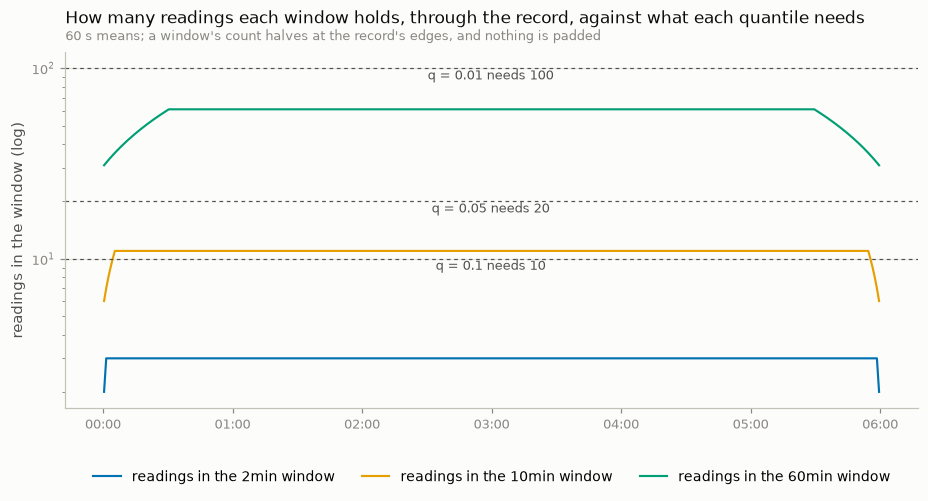

In [8]:
start_section("§3")
data = minute_campaign(duration=DURATION)
stream = measured(data.streams["suite"])
settings = sweep(windows=WINDOWS, quantiles=QUANTILES, min_readings=MIN_READINGS)
minimum = [settings.min_readings_for(q) for q in QUANTILES]

# The warning is part of what this section shows: capture it and print it.
captured = []
handler = logging.Handler()
handler.emit = lambda record: captured.append(record.getMessage())
logging.getLogger("tsara.rolling.state").addHandler(handler)
try:
    state = rolling_state(stream, instrument="suite", baseline=settings)
finally:
    logging.getLogger("tsara.rolling.state").removeHandler(handler)
print(f"readings: {stream.sizes['time']} minute means; a window of 2 min holds at most 3 of them\n")
print("the warning, verbatim:")
print("  " + "\n  ".join(captured) if captured else "  (none)")

counts = state["n_readings_window_ch4"].values  # (time, window)
blank = np.isnan(state["baseline_ch4"].values)  # (time, window, quantile)
recorded = (
    state["baseline_ch4"]
    .attrs["tsara_baseline_blank_fraction"]
    .reshape(len(WINDOWS), len(QUANTILES))
)
print(
    f"\n{'window':>8} "
    + " ".join(f"q={q:<5g}" for q in QUANTILES)
    + "   readings per window (min / median / max)"
)
print(f"{'needs':>8} " + " ".join(f"{m:<7d}" for m in minimum))
for w, window in enumerate(WINDOWS):
    shares = " ".join(f"{recorded[w, j]:<7.0%}" for j in range(len(QUANTILES)))
    spread = f"{counts[:, w].min()} / {int(np.median(counts[:, w]))} / {counts[:, w].max()}"
    print(f"{window:>8} {shares}   {spread}   blank share per quantile")

# Checks against the definition, window by window.
cells = cells_of(stream)
readings = stream["ch4"].values
for w, window in enumerate(WINDOWS):
    for j, q in enumerate(QUANTILES):
        want, count, coverage = reference_rolling(
            cells, readings, pd.Timedelta(window).total_seconds(), q, min_readings=minimum[j]
        )
        check(
            f"§3 blank exactly where the window has under {minimum[j]} readings: {window}, q={q:g}",
            same(state["baseline_ch4"].values[:, w, j], want),
        )
check(
    "§3 the recorded blank fraction per sweep point is the share of readings left blank",
    np.allclose(recorded, blank.mean(axis=0)),
)
fully = [
    f"{window}/{q:g}"
    for w, window in enumerate(WINDOWS)
    for j, q in enumerate(QUANTILES)
    if recorded[w, j] == 1.0
]
named = [
    f"{window}/{q:g}"
    for w, window in enumerate(WINDOWS)
    for j, q in enumerate(QUANTILES)
    if any(f"ch4 at {window}/{q:g}" in message for message in captured)
]
check(
    "§3 the warning names every sweep point blank at every reading, and no other",
    fully == named,
    f"{len(fully)} point(s): {', '.join(fully) or 'none'}",
)
# The edge: the first window at the longest window holds its right half.
longest = len(WINDOWS) - 1
_, first_count, first_coverage = reference_rolling(
    cells, readings, pd.Timedelta(WINDOWS[longest]).total_seconds(), QUANTILES[-1], min_readings=1
)
check(
    f"§3 at the record's edge the {WINDOWS[longest]} window holds its right half: no padding",
    abs(state["coverage_window_ch4"].values[0, longest] - 0.5)
    < 1.5 * 60 / pd.Timedelta(WINDOWS[longest]).total_seconds()
    and counts[0, longest] == first_count[0],
    f"cover  {state['coverage_window_ch4'].values[0, longest]:.3f}, {counts[0, longest]} readings",
)

# Figure only from here: the count in every window through the record, against
# what each quantile needs. Where a line sits below a dashed level, that
# quantile is blank at that window.
fig, ax = plt.subplots(figsize=(10, 4.2))
clock = stream["time"].values
for w, (window, colour) in enumerate(zip(WINDOWS, (C1, C2, C3))):
    ax.plot(clock, counts[:, w], color=colour, lw=1.4, label=f"readings in the {window} window")
middle = clock[len(clock) // 2]
for j, (q, m) in enumerate(zip(QUANTILES, minimum)):
    ax.axhline(m, color=INK2, lw=0.8, ls=(0, (3, 3)))
    ax.text(middle, m, f"q = {q:g} needs {m} ", ha="center", va="top", fontsize=8.5, color=INK2)
ax.set_yscale("log")
finish(
    ax,
    "How many readings each window holds, through the record, against what each quantile needs",
    "60 s means; a window's count halves at the record's edges, and nothing is padded",
    "readings in the window (log)",
    None,
)
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.14))
hhmm(ax)
plt.show()

**What to read off the output.** The table is the state's own record,
`tsara_baseline_blank_fraction`, one number per sweep point. At 2 min every
point is blank for every reading: three minute means cannot make a 10th
percentile, let alone a 1st. At 10 min the window holds eleven readings, so
only *q* = 0.10 (ten needed) is reported; at 60 min the 1st percentile (a
hundred needed) is still blank while the others are fine. The warning names
exactly the points that are blank everywhere, with the count each needed, and
says what to do: a longer window, a lower count, or another method (§5).

The figure is the edge. Each count ramps up over the first half-window and
down over the last: the first 60 min window holds 31 readings, not 61, and its
coverage is 0.5. Nothing was padded or invented; the rule simply decides on
what is there, which for the 60 min window at *q* = 0.05 is still enough.

**Try it.** `MIN_READINGS = 5`: the 10 min window is now reported at every
quantile, and the warning shrinks to the 2 min points. `WINDOWS = ("30min",
"3h", "6h")`: the record is only six hours, so the 6 h window is never full and
its count peaks at the middle of the record. `DURATION = "1h"`: even the 60 min
window is never full, and the *q* = 0.05 point at 60 min is blank near both
ends where fewer than twenty readings fall inside.

---
## 4. The width rule: a reading is not stood on a window narrower than half of it

**The question.** The count rule catches most bad windows first. What is left
for the width rule of `METHODS.md` §6.3, the same `COPY_RATIO = 2` every join
holds to?

A window narrower than half a reading would take its value from a mean over a
much longer interval and call it the local background: the same operation as
copying a 60 s mean onto 1 s cells, which the join refuses (notebook 04, §4).
The count rule usually refuses such a window first, because a window shorter
than half a reading touches at most two readings. The case it does not catch is
an instrument whose cells **overlap**: a running mean logged more often than its
length. Below, a stream reports 60 s means every 30 s, so a 30 s window touches
two or three readings, passes a count of two, and would report a baseline from
readings twice its own width.

In [9]:
# ---- PARAMETERS (section 4) --------------------------------------------------
MEAN_S = 60.0  # how long each reported mean is
EVERY_S = 30.0  # how often one is reported: overlapping cells when shorter than MEAN_S
WINDOW = "30s"  # the window the width rule is asked about
MIN_READINGS = 2  # low on purpose, so the count rule does not decide first

In [10]:
start_section("§4")
n = 240
rng = np.random.default_rng(4)
starts = pd.Timestamp("2026-06-18T12:00:00").value + np.arange(n, dtype=np.int64) * int(
    EVERY_S * SECOND
)
running = make_stream(
    starts,
    starts + int(MEAN_S * SECOND),
    {"ch4": 1900 + rng.normal(0, 0.4, n)},
    cell_methods="time: mean",
)
settings = sweep(windows=(WINDOW, "10min"), quantiles=(0.5,), min_readings=MIN_READINGS)
state = rolling_state(running, instrument="running", baseline=settings)
ratio = MEAN_S / pd.Timedelta(WINDOW).total_seconds()
too_wide = state["baseline_ch4"].attrs["tsara_baseline_too_wide_fraction"]
counts = state["n_readings_window_ch4"].values
print(
    f"a {MEAN_S:g} s mean under a {WINDOW} window: the reading is {ratio:g} x as wide as the window"
)
span = f"{counts[:, 0].min()} to {counts[:, 0].max()}"
print(f"readings in the {WINDOW} window: {span} (the count rule needs {MIN_READINGS})")
print(f"share of windows failing the width rule, per window: {too_wide.tolist()}")
blank_share = np.isnan(state["baseline_ch4"].values[:, :, 0]).mean(axis=0).round(3).tolist()
print(f"blank share, per window: {blank_share}")

blank_short = np.isnan(state["baseline_ch4"].values[:, 0, 0])
if ratio >= 2.0:
    check(
        f"§4 with the reading {ratio:g} x the window, every {WINDOW} window is blank for width",
        blank_short.all() and too_wide[0] == 1.0 and (counts[:, 0] >= MIN_READINGS).all(),
        "the count rule passed; the width rule refused",
    )
else:
    check(
        f"§4 with the reading {ratio:g} x the window (under 2), {WINDOW} is not refused for width",
        too_wide[0] == 0.0,
    )
check(
    "§4 a 10 min window on the same readings is fine",
    too_wide[1] == 0.0 and not np.isnan(state["baseline_ch4"].values[:, 1, 0]).all(),
)

2026-09-28 16:54:32 | WARNING  | tsara.rolling.state | Rolling state of 'running': 1 sweep point(s) are blank at every reading -- ch4 at 30s/0.5 (needs 2 readings). A window that holds fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.


a 60 s mean under a 30s window: the reading is 2 x as wide as the window
readings in the 30s window: 2 to 3 (the count rule needs 2)
share of windows failing the width rule, per window: [1.0, 0.0]
blank share, per window: [1.0, 0.0]
  ✔ §4 with the reading 2 x the window, every 30s window is blank for width   [the count rule passed; the width rule refused]
  ✔ §4 a 10 min window on the same readings is fine


**What to read off the output.** The 30 s windows pass the count (two or three
overlapping readings each) and are still blank: every one of them held a
reading twice its own width, and the state records that as
`tsara_baseline_too_wide_fraction = 1.0` for that window. At 10 min the same
readings are a fifth of the window and the baseline is reported. The line is
exactly 2, as it is for a join, and the reason is the same: a value averaged
over an interval is not the value at a fraction of it.

**Try it.** `WINDOW = "45s"`: the reading is 1.33 × the window, below the line,
so the width rule allows it; what the state reports is then a baseline built
from readings wider than the window, which is *narrowing* as notebook 04 §4
defines it, allowed and recorded there too. `EVERY_S = 60`: the cells no longer
overlap, a 30 s window holds one reading, and the count rule refuses first.

---
## 5. A sparse instrument adopts a dense one's baseline: `from_field` as three calls

**The question.** A canister fills for fifteen seconds every nine minutes. At
the windows where a 1 s analyzer has a baseline it holds one fill (`METHODS.md`
§6.5 measured 54 % of 10 min windows on the real archive). What stands in?

Your decision: options, not one rule. `from_field` adopts **another
instrument's baseline of the same field**, joined onto this instrument's cells:
the atmosphere has one benzene background, and the PTR-MS samples it every
second beside the canister. Because the stages of TSARA hand each other
Datasets and never import each other, this is three calls, shown below one by
one: roll the donor; join its swept baseline onto the adopter's cells with the
ordinary binner (which since Phase 5 averages every version of a swept variable
at once); roll the adopter with the product handed in as `provided=`. The
adopter refuses anything that is not that join: a product the binner did not
make, one on other cells, one at another sweep, or one that is not the donor's
baseline of this field.

In [11]:
# ---- PARAMETERS (section 5) --------------------------------------------------
WINDOWS = ("10min", "60min")  # the sweep's windows
QUANTILE = 0.05  # the sweep's one quantile
FILL_EVERY = "530s"  # how often the canister fills (the archive's median)
FILL_WIDTH = "15s"  # how long a fill lasts
PTR_NOISE_PPB = 0.02  # the dense analyzer's noise (benzene, ppb)

2026-09-28 16:54:32 | WARNING  | tsara.rolling.state | Rolling state of 'iwas': 2 sweep point(s) are blank at every reading -- benzene_can at 10min/0.05 (needs 20 readings); benzene_can at 60min/0.05 (needs 20 readings). A window that holds fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.


ptr: 28800 readings at 1 s;  iwas: 55 fills of 15s every 530s
the canister's own rolling quantile is blank at [1.0, 1.0] of its fills, per window (it needs 20 fills in a window)



adopted baseline: method from_field, from ptr, the join's record straddled / 880 readings
  ✔ §5 the adopted baseline is the donor's, joined onto the canister's cells, exactly
  ✔ §5 the adopted baseline carries the join's record and names the donor
  ✔ §5 the canister's own rolling quantile is blank at every window shorter than it can fill
  ✔ §5 at 60min the adopted baseline is the true air's 0.05 quantile over the fill's window, to within the PTR's noise   [median |adopted - true quantile| 0.022 ppb, PTR noise 0.02 ppb]
  ✔ §5 the canister's enhancement is its fill minus the adopted baseline

without provided=, the adopter says:
  'benzene_can' on 'iwas' adopts its baseline from 'ptr' (from_field), and no product was provided. Roll the donor stream first, join its baseline onto this stream's cells with tsara.align.bin_streams_onto_cells(donor_state, target=this stream's cells), and pass the result as provided={'benzene_can': joined}.
  ✔ §5 without a provided product the adopter re

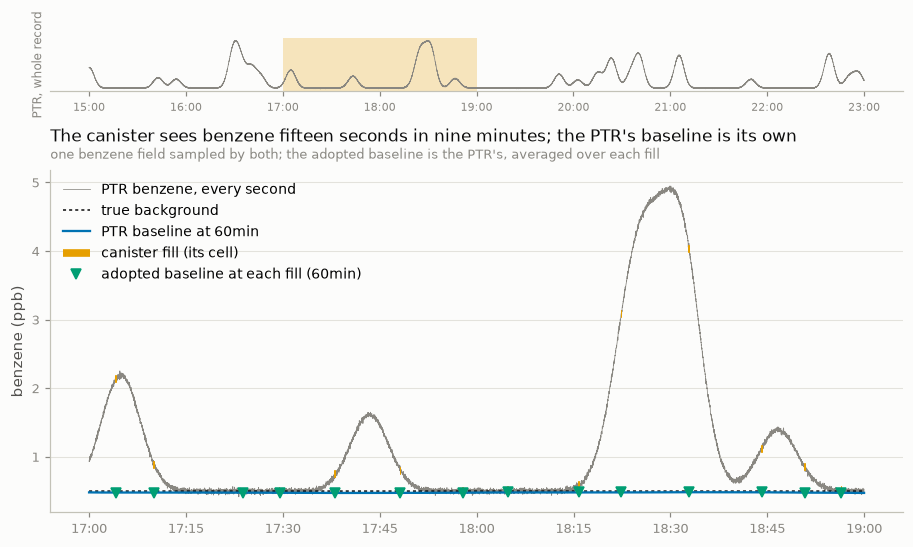

In [12]:
start_section("§5")
data = canister_campaign(fill_every=FILL_EVERY, fill_width=FILL_WIDTH, ptr_noise_ppb=PTR_NOISE_PPB)
ptr, iwas = measured(data.streams["ptr"]), measured(data.streams["iwas"])
settings = sweep(
    windows=WINDOWS,
    quantiles=(QUANTILE,),
    methods={"iwas.benzene_can": {"method": "from_field", "instrument": "ptr"}},
)
print(
    f"ptr: {ptr.sizes['time']} readings at 1 s;  "
    f"iwas: {iwas.sizes['time']} fills of {FILL_WIDTH} every {FILL_EVERY}"
)

# What the canister can do on its own: nothing at these windows.
own = rolling_state(iwas, instrument="iwas", baseline=sweep(windows=WINDOWS, quantiles=(QUANTILE,)))
own_blank = own["baseline_benzene_can"].attrs["tsara_baseline_blank_fraction"]
print(
    f"the canister's own rolling quantile is blank at {own_blank.tolist()} of its fills, "
    f"per window (it needs {settings.min_readings_for(QUANTILE)} fills in a window)"
)

# Call 1: roll the donor.
donor = rolling_state(ptr, instrument="ptr", baseline=settings)
# Call 2: join the donor's swept baseline onto the adopter's cells.
joined = bin_streams_onto_cells(
    {"ptr": donor}, stream_cells(iwas, "iwas"), [("ptr", "baseline_benzene")]
)
# Call 3: roll the adopter with the product provided.
adopter = rolling_state(
    iwas, instrument="iwas", baseline=settings, provided={"benzene_can": joined}
)
base = adopter["baseline_benzene_can"]
print(
    f"\nadopted baseline: method {base.attrs['tsara_baseline_method']}, "
    f"from {base.attrs['tsara_baseline_from']}, the join's record "
    f"{base.attrs['tsara_support_transform']} / {base.attrs['tsara_n_readings']} readings"
)

check(
    "§5 the adopted baseline is the donor's, joined onto the canister's cells, exactly",
    same(base.values, joined["baseline_benzene"].values),
)
check(
    "§5 the adopted baseline carries the join's record and names the donor",
    base.attrs["tsara_baseline_from"] == "ptr" and "tsara_support_transform" in base.attrs,
)
check(
    "§5 the canister's own rolling quantile is blank at every window shorter than it can fill",
    bool((own_blank == 1.0).all()),
)
# Against the answer key. The adopted baseline is the low quantile of the air
# the PTR saw around each fill; the true air (background plus plumes, no noise)
# has its own low quantile over the same window, and the two should differ by
# no more than the PTR's noise. Not the true background: a window that holds a
# plume has a higher low quantile than the background, by physics.
true_air = (
    data.streams["ptr"]["truth_background_benzene"].values
    + data.streams["ptr"]["truth_enhancement_benzene"].values
)
true_quantile = rolling_quantile(
    stream_cells(ptr, "ptr"),
    true_air,
    window_cells(stream_cells(iwas, "iwas"), pd.Timedelta(WINDOWS[-1]).value),
    [QUANTILE],
).values[:, 0]
gap = base.values[:, -1, 0] - true_quantile
check(
    f"§5 at {WINDOWS[-1]} the adopted baseline is the true air's {QUANTILE:g} quantile over "
    "the fill's window, to within the PTR's noise",
    np.nanmedian(np.abs(gap)) < 4 * PTR_NOISE_PPB,
    f"median |adopted - true quantile| {np.nanmedian(np.abs(gap)):.3f} ppb, "
    f"PTR noise {PTR_NOISE_PPB} ppb",
)
check(
    "§5 the canister's enhancement is its fill minus the adopted baseline",
    same(
        adopter["enhancement_benzene_can"].values,
        iwas["benzene_can"].values[:, None, None] - base.values,
    ),
)

# The refusals: what the adopter will not accept as a baseline.
try:
    rolling_state(iwas, instrument="iwas", baseline=settings)
except TsaraRollingError as error:
    print(f"\nwithout provided=, the adopter says:\n  {error}")
    check(
        "§5 without a provided product the adopter refuses and names the three calls",
        "bin_streams_onto_cells" in str(error) and "provided=" in str(error),
    )
elsewhere = bin_streams_onto_cells(
    {"ptr": donor},
    uniform_cells(iwas["time"].values[0], 15.0, len(iwas["time"])),
    [("ptr", "baseline_benzene")],
)
try:
    rolling_state(iwas, instrument="iwas", baseline=settings, provided={"benzene_can": elsewhere})
    check("§5 a product on other cells is refused", False)
except TsaraRollingError as error:
    check(
        "§5 a product on other cells is refused",
        "does not sit on this stream's cells" in str(error),
    )

# Figure only from here.
clock = ptr["time"].values
start = pd.Timestamp(clock[0])
view = (start + pd.Timedelta(hours=2), start + pd.Timedelta(hours=4))
inside = (clock >= np.datetime64(view[0])) & (clock < np.datetime64(view[1]))
fig, (top, ax) = plt.subplots(
    2, 1, figsize=(10, 5.6), gridspec_kw={"height_ratios": [0.5, 3.2], "hspace": 0.4}
)
overview_strip(top, clock, ptr["benzene"].values, view, "PTR, whole record")
t, x = break_gaps(clock[inside], ptr["benzene"].values[inside])
ax.plot(t, x, color=MUTED, lw=0.5, label="PTR benzene, every second")
ax.plot(
    clock[inside],
    data.streams["ptr"]["truth_background_benzene"].values[inside],
    color=INK,
    lw=1.0,
    ls=(0, (2, 2)),
    label="true background",
)
ax.plot(
    clock[inside],
    donor["baseline_benzene"].values[inside, -1, 0],
    color=C1,
    lw=1.5,
    label=f"PTR baseline at {WINDOWS[-1]}",
)
edges = iwas["time_bnds"].values
fill_inside = (edges[:, 0] >= np.datetime64(view[0])) & (edges[:, 1] <= np.datetime64(view[1]))
for k in np.flatnonzero(fill_inside):
    first = k == np.flatnonzero(fill_inside)[0]
    ax.hlines(
        iwas["benzene_can"].values[k],
        edges[k, 0],
        edges[k, 1],
        color=C2,
        lw=5,
        label="canister fill (its cell)" if first else None,
    )
ax.plot(
    iwas["time"].values[fill_inside],
    base.values[fill_inside, -1, 0],
    "v",
    color=C3,
    ms=7,
    label=f"adopted baseline at each fill ({WINDOWS[-1]})",
)
finish(
    ax,
    "The canister sees benzene fifteen seconds in nine minutes; the PTR's baseline is its own",
    "one benzene field sampled by both; the adopted baseline is the PTR's, averaged over each fill",
    "benzene (ppb)",
    None,
    legend=True,
    loc="upper left",
)
hhmm(ax)
plt.show()

**What to read off the output.** The canister's own rolling quantile is blank
everywhere: no 10 min or 60 min window holds the twenty fills the 5th
percentile needs, and the record says so rather than reporting a baseline made
of one fill. After the three calls, each fill (amber bar) has a baseline
(green marker) that is the PTR's 60 min baseline averaged over that fill's
fifteen seconds, and the enhancement is the fill above it. The adopted
baseline carries the join's own record, `averaged` here, since 1 s readings
sit wholly inside a 15 s fill, and names the donor.

The refusals printed above are the point of the three-call design: the
adopter checks what it is handed rather than trusting it, so a product built
on other cells, at another sweep, or from another field cannot be adopted by
accident.

**Try it.** `FILL_EVERY = "120s"` with `WINDOWS = ("60min", "6h")`: the
canister now fills thirty times an hour, its own 60 min window holds about
thirty fills, and `own_blank` at 60 min drops to 0: at that cadence a
canister can see its own background, and `from_field` is a choice rather than
a necessity. `PTR_NOISE_PPB = 0.2`: the adopted baseline sits ten times
further below the true background (a 5th percentile of noisier readings), and
the check's tolerance follows it.

---
## 6. A declared constant: the enhancement is the concentration

**The question.** The third option of §6.5: a baseline declared as a number,
zero included. What does the state do with it, and with the uncertainties?

At zero the enhancement *is* the concentration. A slope fitted inside an event
loses nothing by it (a baseline flat across the event moves the intercept, not
the slope, §6.1), and a receptor model run on concentrations rather than
enhancements is common practice, with the background appearing as a factor of
its own. A constant has no window, no count and no sampling uncertainty, and
nothing about it cancels an error of the reading, so the enhancement inherits
the reading's whole uncertainty.

In [13]:
# ---- PARAMETERS (section 6) --------------------------------------------------
VALUE = 0.0  # the declared baseline, in ppb

In [14]:
start_section("§6")
data = flat_campaign(duration="20min")
stream = measured(data.streams["analyzer"])
# The generator publishes no sigma column unless asked; declare the analyzer's
# true random sigma as its own, the way a manifest would, so the enhancement
# has a sigma to inherit.
stream["sigma_rand_ch4"] = (
    "time",
    data.streams["analyzer"]["truth_sigma_rand_ch4"].values,
    {"units": "ppb", "uncertainty_component": "random", "uncertainty_provenance": "declared"},
)
settings = sweep(methods={"analyzer.ch4": {"method": "constant", "value": VALUE}})
state = rolling_state(stream, instrument="analyzer", baseline=settings)
base = state["baseline_ch4"]
print(
    f"baseline: every value {np.unique(base.values).tolist()} ppb; attrs name the method "
    f"and value: {base.attrs['tsara_baseline_method']}, {base.attrs['tsara_baseline_value']}"
)
print(f"columns: {sorted(v for v in state.data_vars if str(v).endswith('ch4'))}")
check(
    "§6 the baseline is the constant at every reading and sweep point",
    bool((base.values == VALUE).all()),
)
check(
    "§6 the enhancement is the reading minus the constant, at every sweep point",
    same(
        state["enhancement_ch4"].values,
        np.broadcast_to(stream["ch4"].values[:, None, None] - VALUE, base.shape),
    ),
)
absent = ("n_readings_window_ch4", "coverage_window_ch4", "sigma_rand_baseline_ch4")
check(
    "§6 a constant has no window count, no coverage and no sampling sigma",
    all(name not in state.data_vars for name in absent),
)
check(
    "§6 the enhancement's random sigma is the reading's, unchanged (nothing cancels)",
    same(
        state["sigma_rand_enhancement_ch4"].values,
        np.broadcast_to(stream["sigma_rand_ch4"].values[:, None, None], base.shape),
    ),
)

baseline: every value [0.0] ppb; attrs name the method and value: constant, 0.0
columns: ['baseline_ch4', 'ch4', 'enhancement_ch4', 'noise_ch4', 'sigma_rand_ch4', 'sigma_rand_enhancement_ch4']
  ✔ §6 the baseline is the constant at every reading and sweep point
  ✔ §6 the enhancement is the reading minus the constant, at every sweep point
  ✔ §6 a constant has no window count, no coverage and no sampling sigma
  ✔ §6 the enhancement's random sigma is the reading's, unchanged (nothing cancels)


**What to read off the output.** No window companions, no baseline sigma, and
the enhancement's sigma is the reading's own. The attributes still say what
the baseline is (`constant`, and the value), so a product built on this state
later can say which baseline it rests on.

**Try it.** `VALUE = 1900.0`: the enhancement is now the noise around the
background, positive and negative, and its sigma is still the reading's.

---
## 7. The uncertainty of a baseline, and of an enhancement

**The question.** A baseline is a low quantile of noisy readings, so it has a
sampling uncertainty of its own; an enhancement is a reading minus that
baseline. What does the state write for each, and is it right?

`METHODS.md` §6.7 decides both. **The baseline's** random sigma is Woodruff's
order-statistic interval: read the same sorted window at *q* ± √(*q*(1−*q*)/*N*),
report half the interval. It assumes the readings in a window are exchangeable
draws, which air is not, so it is labelled a **floor**. **The enhancement's**
random sigma adds the reading's and the baseline's in quadrature. Its
systematic sigma depends on where the baseline came from: an error common to
reading and baseline is either an *offset*, which cancels in the difference,
or a *gain*, which scales it, so for a same-instrument baseline TSARA writes
σ_sys(*x*)·|Δ|/|*x*|, exact for a gain error and an upper bound otherwise. Both
claims are checked below against draws whose truth is known, and against a
manufactured error whose kind is known.

In [15]:
# ---- PARAMETERS (section 7) --------------------------------------------------
N_PER_WINDOW = 200  # readings in each independent window of the Monte Carlo
N_WINDOWS = 1500  # how many independent windows are drawn
Q = 0.05  # the quantile whose sigma is scored
RHO = 0.99  # lag-one correlation of the "air" in the second draw: what the floor is a floor against
GAIN = 0.02  # a 2 % gain error, applied to every reading of the manufactured record
OFFSET_PPB = 15.0  # a 15 ppb offset error, applied the same way

In [16]:
start_section("§7")
rng = np.random.default_rng(7)

# --- Woodruff against the scatter of the estimator ---------------------------
# Independent standard-normal windows: the sigma the state reports for each
# window's quantile, against how much that quantile actually scatters from
# window to window, and how often the reported interval holds the truth.
cells = uniform_cells("2026-01-01", 1.0, N_PER_WINDOW * N_WINDOWS)
draws = rng.standard_normal(N_PER_WINDOW * N_WINDOWS)
windows = uniform_cells("2026-01-01", float(N_PER_WINDOW), N_WINDOWS)
rolled = rolling_quantile(cells, draws, windows, [Q])
truth = float(np.quantile(rng.standard_normal(2_000_000), Q))
estimates, sigmas = rolled.values[:, 0], rolled.sigma[:, 0]
ratio = float(np.mean(sigmas) / np.std(estimates))
covered = float(np.mean(np.abs(estimates - truth) <= sigmas))
print(
    f"independent draws, N = {N_PER_WINDOW}, q = {Q}: reported sigma / observed scatter "
    f"= {ratio:.3f}; the interval holds the true quantile in {covered:.0%} of windows"
)
check(
    "§7 Woodruff's sigma equals the reference written from its definition, window by window",
    np.allclose(
        sigmas[:50],
        [
            reference_woodruff(
                draws[k * N_PER_WINDOW : (k + 1) * N_PER_WINDOW], np.ones(N_PER_WINDOW), Q
            )
            for k in range(50)
        ],
        rtol=1e-9,
    ),
    "the first fifty windows",
)
check(
    "§7 on independent draws the reported sigma is the scatter of the estimate to within a factor",
    0.8 < ratio < 1.3 and 0.58 < covered < 0.78,
    f"ratio {ratio:.2f}, coverage {covered:.0%}; METHODS §6.7 measured 1.03 and 0.66 "
    "at N = 200, q = 0.05",
)

# The floor: on strongly autocorrelated "air" the readings in a window are not
# exchangeable, the quantile scatters far more from window to window than the
# within-window spread suggests, and the reported figure is a fraction of it.
noise = rng.standard_normal(N_PER_WINDOW * N_WINDOWS)
air = np.empty_like(noise)
air[0] = noise[0]
scale = np.sqrt(1 - RHO**2)
for i in range(1, air.size):
    air[i] = RHO * air[i - 1] + scale * noise[i]
rolled_air = rolling_quantile(cells, air, windows, [Q])
ratio_air = float(np.mean(rolled_air.sigma[:, 0]) / np.std(rolled_air.values[:, 0]))
print(f"AR(1) air, lag-one correlation {RHO}: reported sigma / observed scatter = {ratio_air:.3f}")
check(
    "§7 on autocorrelated air the reported sigma is a floor: well below the true scatter",
    ratio_air < 0.5 * ratio,
    f"ratio {ratio_air:.2f} against {ratio:.2f} on independent draws; the attribute says 'floor'",
)

# --- the enhancement's systematic sigma: a gain scales it, an offset cancels --
# A noise-free record, then the SAME error applied to every reading, so that
# the baseline inherits it exactly as a real calibration error would.
data = landfill_campaign(duration="3h", noise_ppb=None, blips_per_hour=6.0)
clean = measured(data.streams["analyzer"])
settings = sweep(windows=("2min", "60min"), quantiles=(Q,))
true_state = rolling_state(clean, instrument="analyzer", baseline=settings)
delta_true = true_state["enhancement_ch4"].values


def with_error(gain, offset, declared):
    """Return the clean stream as (1 + gain) * true + offset, its systematic sigma declared."""
    wrong = clean.copy(deep=True)
    wrong["ch4"] = wrong["ch4"] * (1 + gain) + offset
    wrong["sigma_sys_ch4"] = (
        "time",
        declared,
        {
            "units": "ppb",
            "uncertainty_component": "systematic",
            "uncertainty_provenance": "declared",
        },
    )
    return wrong


x = clean["ch4"].values
for label, gain, offset in (
    ("a pure gain error", GAIN, 0.0),
    ("a pure offset error", 0.0, OFFSET_PPB),
):
    declared = np.abs(gain) * x + abs(offset)  # what a manifest would declare per point
    state = rolling_state(
        with_error(gain, offset, declared), instrument="analyzer", baseline=settings
    )
    delta = state["enhancement_ch4"].values
    figure = state["sigma_sys_enhancement_ch4"].values
    actual = np.abs(delta - delta_true)
    finite = np.isfinite(actual) & np.isfinite(figure) & (np.abs(delta_true) > 5.0)
    rule = state["sigma_sys_enhancement_ch4"].attrs["tsara_sigma_rule"]
    print(f"\n{label}: rule '{rule}'")
    print(
        f"  median actual |Δ error| {np.median(actual[finite]):.3f} ppb, "
        f"median reported sigma {np.median(figure[finite]):.3f} ppb"
    )
    if gain:
        check(
            f"§7 under {label} the reported systematic sigma of Δ is the actual error, exactly",
            np.allclose(actual[finite], figure[finite], rtol=1e-6, atol=1e-9),
        )
    else:
        check(
            f"§7 under {label} the error of Δ is nil and the reported sigma bounds it above",
            np.nanmax(actual[finite]) < 1e-6 and bool((figure[finite] >= actual[finite]).all()),
            f"reported {np.median(figure[finite]):.3f} ppb where the true error is 0: "
            "the bound, not the value",
        )

# --- the enhancement's random sigma: the reading's and the baseline's in quadrature
noisy = landfill_campaign(duration="3h", noise_ppb=0.7, blips_per_hour=6.0)
stream = measured(noisy.streams["analyzer"])
stream["sigma_rand_ch4"] = (
    "time",
    noisy.streams["analyzer"]["truth_sigma_rand_ch4"].values,
    {"units": "ppb", "uncertainty_component": "random", "uncertainty_provenance": "declared"},
)
state = rolling_state(stream, instrument="analyzer", baseline=settings)
want = np.sqrt(
    stream["sigma_rand_ch4"].values[:, None, None] ** 2
    + state["sigma_rand_baseline_ch4"].values ** 2
)
got = state["sigma_rand_enhancement_ch4"].values
finite = np.isfinite(got)
check(
    "§7 the enhancement's random sigma is the reading's and the baseline's in quadrature",
    np.allclose(got[finite], want[finite]),
)
print(
    f"\nwith 0.7 ppb of noise, the enhancement's random sigma is {np.nanmedian(got):.3f} ppb: "
    f"the reading's noise, plus a baseline sigma of "
    f"{np.nanmedian(state['sigma_rand_baseline_ch4'].values):.3f} ppb in quadrature"
)

independent draws, N = 200, q = 0.05: reported sigma / observed scatter = 1.043; the interval holds the true quantile in 66% of windows
  ✔ §7 Woodruff's sigma equals the reference written from its definition, window by window   [the first fifty windows]
  ✔ §7 on independent draws the reported sigma is the scatter of the estimate to within a factor   [ratio 1.04, coverage 66%; METHODS §6.7 measured 1.03 and 0.66 at N = 200, q = 0.05]


AR(1) air, lag-one correlation 0.99: reported sigma / observed scatter = 0.077
  ✔ §7 on autocorrelated air the reported sigma is a floor: well below the true scatter   [ratio 0.08 against 1.04 on independent draws; the attribute says 'floor']



a pure gain error: rule 'same instrument: sigma_sys(x) |enhancement| / |x|'
  median actual |Δ error| 0.692 ppb, median reported sigma 0.692 ppb
  ✔ §7 under a pure gain error the reported systematic sigma of Δ is the actual error, exactly



a pure offset error: rule 'same instrument: sigma_sys(x) |enhancement| / |x|'
  median actual |Δ error| 0.000 ppb, median reported sigma 0.266 ppb
  ✔ §7 under a pure offset error the error of Δ is nil and the reported sigma bounds it above   [reported 0.266 ppb where the true error is 0: the bound, not the value]


  ✔ §7 the enhancement's random sigma is the reading's and the baseline's in quadrature

with 0.7 ppb of noise, the enhancement's random sigma is 0.701 ppb: the reading's noise, plus a baseline sigma of 0.034 ppb in quadrature


**What to read off the output.** On independent draws Woodruff's sigma is the
scatter of the estimate to within a few percent, and its interval holds the
truth about two thirds of the time, which is what a one-sigma figure means.
On air correlated at 0.99 per reading the same figure is a small fraction of
the true scatter: a window of such air holds far fewer independent draws than
readings. That is why the state labels the figure a floor in
`tsara_sigma_assumption` rather than calling it the baseline's uncertainty; the
spread that matters, across windows and quantiles, is the sweep's, and Phase 7
reads it.

The gain-and-offset pair is §6.7's argument run rather than reasoned. Under a
2 % gain error every reading and every baseline is 2 % high, the enhancement is
2 % high, and the state's σ_sys(*x*)·|Δ|/|*x*| is that error exactly. Under a
15 ppb offset the enhancement is untouched, because the offset cancels in the
difference, and the state's figure is an upper bound of a few tenths of a ppb.
The stream cannot say which kind of error it carries, so the bound is what is
written; a 1 % gain error on 1900 ppb is 19 ppb on the reading and under a ppb
on a typical enhancement, which is the number a regression should see.

**Try it.** `RHO = 0.5`: mildly correlated air, and the floor is only mildly
low. `N_PER_WINDOW = 50`: fewer readings, and Woodruff runs a little high (the
interval is asymmetric in the tail; METHODS §6.7 tabulates it). `GAIN = 0.10`:
still exact, since the argument is algebraic.

---
## 8. The noise scale: declared when there is one, estimated when there is not

**The question.** Detection (Phase 6) finds plumes as enhancements above the
noise, in units of a sigma. Where does that sigma come from, and what does the
estimate cost on a record full of plumes?

The ladder (`METHODS.md` §2.3, §2.5; `noise_scale` in
`src/tsara/rolling/noise.py`): a variable with a declared or reported random
sigma gets it as it stands, labelled with its provenance; otherwise the
estimator the detection config names runs, and the result is `empirical`. The
default estimator, `diff_mad`, is the median absolute difference between
consecutive readings, scaled to a sigma: differencing cancels everything slow,
so a broad plume barely moves it. Three rules go with it, all of them from your
additions to the plan: a difference across a **dropout** (readings farther
apart than 1.5 × the record's median spacing) is dropped, because it measures
the air between them; a window with fewer than ten samples is blank; and every
estimate is **floored** at δ/√12, δ being the resolution a logger writes in,
because a record written in steps has a median difference of zero.

In [17]:
# ---- PARAMETERS (section 8) --------------------------------------------------
NOISE_PPB = 0.7  # the analyzer's true white noise on clean air
STEP_PPB = 2.0  # the rounding step of the "logger" record, coarser than the noise: the floor acts
NOISE_WINDOW = "10min"  # the estimator's window (DetectionConfig.noise_window)
GAP_MINUTES = 3  # a masked stretch in the clean record, with a 40 ppb step across it

  ✔ §8 a reported sigma tops the ladder: copied as it stands, labelled, no estimator run


clean air, true sigma 0.70 ppb: diff_mad estimates 0.697 ppb (empirical, diff_mad, floor raised 0% of readings)
  ✔ §8 diff_mad equals the reference written from its definition, window by window
  ✔ §8 on clean air the estimate is the true sigma to within a few percent   [ratio 0.996]



the same air written in 2.0 ppb steps: 72% of consecutive differences are exactly zero; the estimate is floored at 2.0/sqrt(12) = 0.577 ppb on 100% of readings (resolution recorded: 2)
  ✔ §8 where more than half the differences are zero the estimate is the floor delta/sqrt(12)



a 3 min dropout with a 40 ppb step across it: with the rule, the estimate near the gap peaks at 0.72 ppb; without it, at 1.08 ppb
  ✔ §8 a difference across a dropout is dropped, so a step over a gap does not inflate the noise



the example campaign's 2 s Picarro: 30% of readings inside plumes; diff_mad reads 1.30 x the true sigma (METHODS §2.5 measured 1.30 at 10 min)
  ✔ §8 on a plume-dense record the estimate is biased high, by the measured factor   [1.30; the remedy is Phase 6's: re-estimate outside detected plumes]


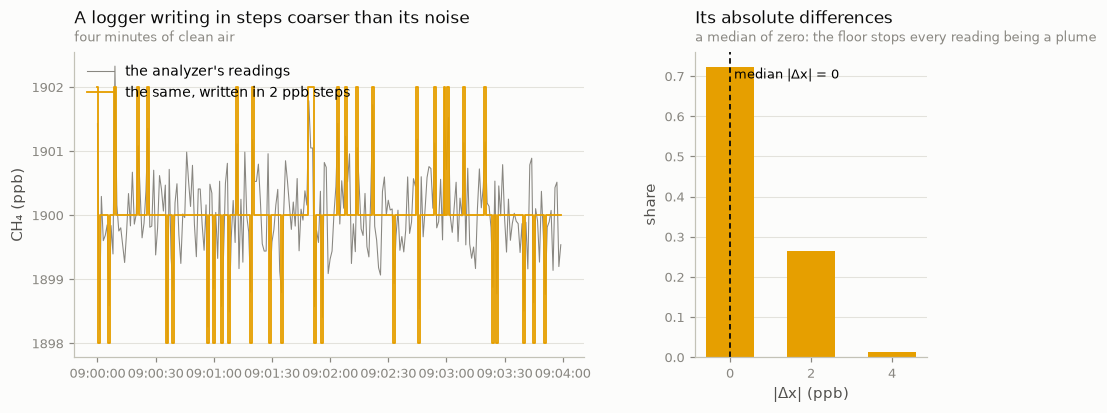

In [18]:
start_section("§8")
from tsara import load_synthetic  # noqa: E402  (the example campaign, the plume-dense case)

detection = DetectionConfig(noise_window=NOISE_WINDOW)

# --- the top of the ladder: a declared sigma is copied, labelled, unfloored --
data = flat_campaign(duration="1h", noise_ppb=NOISE_PPB)
stream = measured(data.streams["analyzer"])
declared = stream.copy()
declared["sigma_rand_ch4"] = (
    "time",
    np.full(stream.sizes["time"], 0.5),
    {"units": "ppb", "uncertainty_provenance": "reported"},
)
top = rolling_state(
    declared,
    instrument="analyzer",
    baseline=sweep(windows=("2min",), quantiles=(0.05,)),
    noise=detection,
)["noise_ch4"]
check(
    "§8 a reported sigma tops the ladder: copied as it stands, labelled, no estimator run",
    bool((top.values == 0.5).all())
    and top.attrs["uncertainty_provenance"] == "reported"
    and "tsara_noise_estimator" not in top.attrs,
)

# --- clean air: the estimate is the truth, and it is the definition ------------
cells = cells_of(stream)
truth_sigma = data.streams["analyzer"]["truth_sigma_rand_ch4"].values
estimate = noise_scale(
    stream, "ch4", cells, estimator="diff_mad", window_ns=pd.Timedelta(NOISE_WINDOW).value
)
reference = reference_diff_mad(
    cells, stream["ch4"].values, pd.Timedelta(NOISE_WINDOW).total_seconds()
)
inside = np.isfinite(estimate.sigma) & np.isfinite(reference)
print(
    f"clean air, true sigma {np.median(truth_sigma):.2f} ppb: diff_mad estimates "
    f"{np.nanmedian(estimate.sigma):.3f} ppb ({estimate.provenance}, {estimate.estimator}, "
    f"floor raised {estimate.floor_fraction:.0%} of readings)"
)
check(
    "§8 diff_mad equals the reference written from its definition, window by window",
    np.allclose(estimate.sigma[inside], reference[inside], rtol=1e-9),
)
check(
    "§8 on clean air the estimate is the true sigma to within a few percent",
    abs(np.nanmedian(estimate.sigma) / np.median(truth_sigma) - 1) < 0.06,
    f"ratio {np.nanmedian(estimate.sigma) / np.median(truth_sigma):.3f}",
)

# --- a logger writing in steps: the floor ------------------------------------
stepped = measured(
    flat_campaign(duration="1h", noise_ppb=NOISE_PPB, quantization=STEP_PPB).streams["analyzer"]
)
floored = noise_scale(
    stepped,
    "ch4",
    cells_of(stepped),
    estimator="diff_mad",
    window_ns=pd.Timedelta(NOISE_WINDOW).value,
)
zero_share = float(np.mean(np.diff(stepped["ch4"].values) == 0))
print(
    f"\nthe same air written in {STEP_PPB} ppb steps: {zero_share:.0%} of consecutive "
    f"differences are exactly zero; the estimate is floored at {STEP_PPB}/sqrt(12) = "
    f"{STEP_PPB / np.sqrt(12):.3f} ppb on {floored.floor_fraction:.0%} of readings "
    f"(resolution recorded: {floored.resolution:g})"
)
if zero_share > 0.5:
    check(
        "§8 where more than half the differences are zero the estimate is the floor delta/sqrt(12)",
        np.allclose(floored.sigma[np.isfinite(floored.sigma)], STEP_PPB / np.sqrt(12))
        and floored.resolution == STEP_PPB,
    )
else:
    check(
        "§8 with fewer than half the differences at zero the estimate is above the floor",
        np.nanmin(floored.sigma) >= STEP_PPB / np.sqrt(12),
    )

# --- a dropout with a step across it: the difference is dropped ---------------
gapped = stream.copy(deep=True)
values = gapped["ch4"].values.copy()
half = values.size // 2
values[half:] += 40.0  # the air is 40 ppb higher after the gap
values[half - 60 * GAP_MINUTES // 2 : half + 60 * GAP_MINUTES // 2] = (
    np.nan
)  # the instrument was down
gapped["ch4"] = ("time", values, dict(stream["ch4"].attrs))
kept = noise_scale(
    gapped,
    "ch4",
    cells_of(gapped),
    estimator="diff_mad",
    window_ns=pd.Timedelta(NOISE_WINDOW).value,
)
if_kept = reference_diff_mad(
    cells_of(gapped), values, pd.Timedelta(NOISE_WINDOW).total_seconds(), factor=np.inf
)
near = slice(half - 400, half + 400)
print(
    f"\na {GAP_MINUTES} min dropout with a 40 ppb step across it: with the rule, the estimate "
    f"near the gap peaks at {np.nanmax(kept.sigma[near]):.2f} ppb; without it, "
    f"at {np.nanmax(if_kept[near]):.2f} ppb"
)
check(
    "§8 a difference across a dropout is dropped, so a step over a gap does not inflate the noise",
    np.nanmax(kept.sigma[near]) < 1.5 * NOISE_PPB,
)

# --- a plume-dense record: what the estimate costs ----------------------------
example = generate(load_synthetic(EXAMPLE_CONFIG))
picarro = example.streams["picarro"].drop_vars(["sigma_rand_ch4", "sigma_sys_ch4"], errors="ignore")
dense = noise_scale(
    picarro,
    "ch4",
    stream_cells(picarro, "picarro"),
    estimator="diff_mad",
    window_ns=pd.Timedelta(NOISE_WINDOW).value,
)
true_dense = picarro["truth_sigma_rand_ch4"].values
in_plume = picarro["truth_enhancement_ch4"].values > 3 * true_dense
ratio_dense = float(np.nanmedian(dense.sigma / true_dense))
print(
    f"\nthe example campaign's 2 s Picarro: {in_plume.mean():.0%} of readings inside plumes; "
    f"diff_mad reads {ratio_dense:.2f} x the true sigma (METHODS §2.5 measured 1.30 at 10 min)"
)
check(
    "§8 on a plume-dense record the estimate is biased high, by the measured factor",
    1.1 < ratio_dense < 1.5,
    f"{ratio_dense:.2f}; the remedy is Phase 6's: re-estimate outside detected plumes",
)

# Figure only from here: the stepped record and its differences.
fig, (ax, axd) = plt.subplots(
    1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [2.2, 1.0], "wspace": 0.3}
)
clock = stepped["time"].values[:240]
ax.plot(clock, stream["ch4"].values[:240], color=MUTED, lw=0.7, label="the analyzer's readings")
ax.step(
    clock,
    stepped["ch4"].values[:240],
    where="mid",
    color=C2,
    lw=1.2,
    label=f"the same, written in {STEP_PPB:g} ppb steps",
)
finish(
    ax,
    "A logger writing in steps coarser than its noise",
    "four minutes of clean air",
    "CH₄ (ppb)",
    None,
    legend=True,
    loc="upper left",
)
hhmm(ax, "%H:%M:%S")
diffs = np.abs(np.diff(stepped["ch4"].values))
levels, counts = np.unique(diffs, return_counts=True)
axd.bar(levels, counts / counts.sum(), width=STEP_PPB * 0.6, color=C2)
axd.axvline(np.median(diffs), color=INK, lw=1.2, ls=(0, (3, 2)))
axd.text(
    np.median(diffs),
    0.95,
    f" median |Δx| = {np.median(diffs):g}",
    transform=axd.get_xaxis_transform(),
    fontsize=8.5,
    va="top",
)
finish(
    axd,
    "Its absolute differences",
    "a median of zero: the floor stops every reading being a plume",
    "share",
    "|Δx| (ppb)",
)
plt.show()

**What to read off the output.** Three regimes. On clean air the estimator is
the truth within a few percent and equals the loop written from the definition.
On a record written in steps coarser than the noise, most consecutive
differences are exactly zero (the bars), the median difference is zero, and
the floor δ/√12 is what the state reports instead of a noise scale of zero,
which would make every reading a plume. On the plume-dense example campaign
the estimate runs about 30 % high, because a third of the readings sit inside
plumes whose slopes exceed the noise per step and a window's median difference
lands near the 70th percentile of the noise differences. That is a bias in the
safe direction for detection thresholds, and it is a bias; the fix belongs to
Phase 6, which is the first stage that knows where the plumes are and can
estimate the noise outside them.

**Try it.** `STEP_PPB = 0.2`: finer than the noise, few differences are zero,
and the estimate is the truth again with the floor never raised. `NOISE_WINDOW
= "2min"`: fewer samples per window, a jumpier estimate, and near the dropout
some windows fall below ten samples and go blank. `GAP_MINUTES = 0.5`: a gap of
thirty seconds is still a dropout by the spacing rule, and the step is still
dropped.

---
## 9. The state saves, reloads exactly, and joins like a stream

**The question.** Rolling a campaign is the second slowest step after
ingesting it, so the state must survive a save and a reload without losing a
bit, and what comes back must be usable by every later stage: joined onto
other cells the way a stream is.

`save_state` writes one netCDF file per instrument into a bundle beside the
streams, with the analysis configuration that produced them; `load_state`
brings them back (`src/tsara/rolling/bundle.py`). A reloaded state keeps each
reading's cell, so the binner of Phase 4 puts its baseline and enhancement on
any cells a question names, every version of the sweep at once (§11.2 of
`METHODS.md`, *swept variables*). Below, the state is put on 60 s cells: one
row per minute, one column per sweep point, the receptor-row shape.

In [19]:
# ---- PARAMETERS (section 9) --------------------------------------------------
CELL_S = 60.0  # the cells the reloaded state is joined onto
COMPRESSION = 4  # zlib level for the second save, or None

In [20]:
start_section("§9")
data = landfill_campaign(duration="2h")
stream = measured(data.streams["analyzer"])
settings = sweep()
states = {"analyzer": rolling_state(stream, instrument="analyzer", baseline=settings)}
from tsara.config.analysis import AnalysisConfig  # noqa: E402

analysis = AnalysisConfig(baseline=settings, regression={"reference_species": "ch4"})
plain = save_state(states, WORK / "plain", analysis=analysis)
small = save_state(states, WORK / "small", analysis=analysis, compression=COMPRESSION)
back = load_state(WORK / "plain")
again = back.states["analyzer"]
size_plain, size_small = (
    (plain / "analyzer.nc").stat().st_size,
    (small / "analyzer.nc").stat().st_size,
)
print(
    f"written: {sorted(p.name for p in plain.iterdir())}; {size_plain / 1e6:.1f} MB plain, "
    f"{size_small / 1e6:.1f} MB at zlib level {COMPRESSION}"
)


def identical(a, b):
    """Every variable and coordinate exactly, every attribute exactly, arrays included."""
    if sorted(map(str, a.variables)) != sorted(map(str, b.variables)):
        return False
    for name in a.variables:
        if not same(a[name].values, b[name].values):
            return False
        for key, value in a[name].attrs.items():
            if name == "time" and key == "bounds":
                continue  # moved into encoding on load, by xarray's CF decoding
            other = b[name].attrs.get(key)
            if isinstance(value, np.ndarray):
                if not np.array_equal(value, other):
                    return False
            elif value != other:
                return False
    return a.attrs == b.attrs


check(
    "§9 the reloaded state is the saved one, every variable and attribute exactly",
    identical(states["analyzer"], again),
)
check(
    "§9 the compressed file reloads to the same state and is smaller",
    identical(again, load_state(WORK / "small").states["analyzer"]) and size_small < size_plain,
)
check("§9 the analysis configuration comes back beside the states", back.analysis == analysis)

# Joined like a stream: the reloaded state's swept variables onto minute cells.
cells = uniform_cells(again["time"].values[0], CELL_S, int(np.ceil(again.sizes["time"] / CELL_S)))
joined = bin_streams_onto_cells(
    {"analyzer": again},
    cells,
    [("analyzer", "enhancement_ch4"), ("analyzer", "baseline_ch4"), ("analyzer", "ch4")],
)
print(f"\njoined onto {CELL_S:g} s cells: {dict(joined.sizes)}")
print(f"columns: {sorted(map(str, joined.data_vars))[:8]} ...")
one_by_one = np.empty_like(joined["enhancement_ch4"].values)
for w in range(joined.sizes["baseline_window"]):
    for q in range(joined.sizes["baseline_quantile"]):
        version = (
            again[["enhancement_ch4"]]
            .isel(baseline_window=w, baseline_quantile=q)
            .drop_vars(["baseline_window", "baseline_quantile"])
        )
        version.coords["time_bnds"] = again["time_bnds"]
        one_by_one[:, w, q] = bin_streams_onto_cells({"analyzer": version}, cells)[
            "enhancement_ch4"
        ].values
check(
    "§9 every version of the swept enhancement is joined as it would be joined alone",
    same(joined["enhancement_ch4"].values, one_by_one),
)
# The join of a difference is the difference of the joins only where the same
# readings contributed to all three columns: a cell holding a blank baseline
# averages fewer readings into the baseline than into the reading.
same_readings = (
    joined["n_readings_enhancement_ch4"].values == joined["n_readings_ch4"].values[:, None, None]
) & (joined["n_readings_enhancement_ch4"].values == joined["n_readings_baseline_ch4"].values)
difference = joined["ch4"].values[:, None, None] - joined["baseline_ch4"].values
check(
    "§9 where the same readings formed all three columns, the joined enhancement is the joined "
    "reading minus the joined baseline",
    np.allclose(joined["enhancement_ch4"].values[same_readings], difference[same_readings])
    and same_readings.mean() > 0.5,
    f"{same_readings.mean():.0%} of cells; the rest hold a blank baseline for some reading",
)
table = pd.DataFrame(
    {
        "minute": pd.to_datetime(joined["time"].values[:6]).strftime("%H:%M"),
        "ch4": joined["ch4"].values[:6].round(1),
        **{
            f"Δ @{w}/{q:g}": joined["enhancement_ch4"]
            .sel(baseline_window=pd.Timedelta(w).total_seconds(), baseline_quantile=q)
            .values[:6]
            .round(1)
            for w in settings.windows[::2]
            for q in settings.quantiles[1:2]
        },
    }
)
print("\nthe first six rows, a few of the sweep's columns:")
print(table.to_string(index=False))

written: ['analysis.yaml', 'analyzer.nc']; 2.2 MB plain, 0.9 MB at zlib level 4
  ✔ §9 the reloaded state is the saved one, every variable and attribute exactly
  ✔ §9 the compressed file reloads to the same state and is smaller
  ✔ §9 the analysis configuration comes back beside the states

joined onto 60 s cells: {'time': 120, 'baseline_window': 3, 'baseline_quantile': 3, 'nv': 2}
columns: ['baseline_ch4', 'borrowed_baseline_ch4', 'borrowed_ch4', 'borrowed_enhancement_ch4', 'ch4', 'coverage_baseline_ch4', 'coverage_ch4', 'coverage_enhancement_ch4'] ...
  ✔ §9 every version of the swept enhancement is joined as it would be joined alone
  ✔ §9 where the same readings formed all three columns, the joined enhancement is the joined reading minus the joined baseline   [100% of cells; the rest hold a blank baseline for some reading]

the first six rows, a few of the sweep's columns:
minute    ch4  Δ @2min/0.05  Δ @60min/0.05
 10:00 1900.1           1.2            1.1
 10:01 1900.1          

**What to read off the output.** The round trip loses nothing: values,
coordinates, the cell boundaries, and the per-sweep-point records that are
arrays in the attributes all come back equal. Compression is a choice at save
time and changes only the size. And the reloaded state joins as a stream does:
one call puts every version of the enhancement on minute cells, and each
version equals what joining it alone would give, so a receptor-model matrix is
still "the binner called with a chosen set of columns", now with a sweep
inside.

**Try it.** `CELL_S = 600`: ten-minute rows, and the enhancement at the 2 min
window averages to nearly zero in most rows (the blips are short), while the
2 h window's enhancement keeps the landfill. `COMPRESSION = None`: the two
files are the same size and the check about size fails, as it should.

---
## 10. Scoreboard, and what is known to be imperfect

Every check in this notebook, as it ran. Then the limits this phase records
rather than resolves.

In [21]:
held = sum(1 for ok, _ in CHECKS.values() if ok)
print(f"{held} of {len(CHECKS)} checks hold\n")
for claim, (ok, detail) in CHECKS.items():
    print(f"  {'✔' if ok else '✘'} {claim}" + (f"   [{detail}]" if detail else ""))

57 of 57 checks hold

  ✔ §1 TSARA's weighted quantile equals the one written from the definition
  ✔ §1 with equal weights it is numpy's Hazen rule, at every q
  ✔ §1 the order of the readings does not matter
  ✔ §1 a reading with no weight, or no value, takes no part
  ✔ §2 the baseline at 2min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2min
  ✔ §2 the baseline at 20min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 20min
  ✔ §2 the baseline at 2h is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2h
  ✔ §2 the enhancement is the reading minus the baseline, blank where either is
  ✔ §2 enhancements are never clipped: noise below the baseline stays negative
  ✔ §2 the baseline carries no cell_methods; the enhancement inherits the reading's
  ✔ §2 in clean air the 2min baseline sits z_q·σ below the true background   [median -1.15 ppb, 

### Known to be imperfect, and where each is written down

* **Woodruff's sigma is a floor** on the baseline's sampling error, exact only
  for exchangeable readings; on autocorrelated air it understates the scatter
  by a large factor (§7 above; `METHODS.md` §6.7 measured 0.08 at a lag-one
  correlation of 0.99). The attribute says so. The spread across the sweep is
  Phase 7's to read.
* **The difference estimator is biased high on plume-dense records**, by about
  30 % on the example campaign (§8; `METHODS.md` §2.5). A bias in the safe
  direction for thresholds, and a bias. The remedy, re-estimating outside
  detected plumes, needs detection, and is Phase 6's.
* **A window is a duration.** On a moving platform it is a stretch of road as
  much as an interval of air, so the baseline inherits the cell model's open
  limitation (CLAUDE.md, open flags; `METHODS.md` §6.3) rather than resolving it.
* **`from_field` is three calls**, because the stages of TSARA hand each other
  Datasets and never import each other (§5). The Phase-9 pipeline will make it
  one line; until then the three calls are the honest form.
* **The rolling engine is eager and block-bounded.** A six-hour window on a
  10 Hz record fits in memory and would take hours; `METHODS.md` §6.3 gives the
  arithmetic and names the sorted-sweep form as the upgrade path if such a
  record arrives.
* **The signal-MAD estimator is kept for comparison** and, as built, takes each
  reading's residual against its own window's median, which high-passes a broad
  plume; it does not collapse on one the way the textbook rolling MAD would
  (`METHODS.md` §2.5 says what was measured).